# Import Libraries

In [1]:
# Importing relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

# Loading CAR Data

In [2]:
# data path (NOTE: CHANGE THIS DEPENDING ON THE PARTICULAR PATH WHERE YOU STORE THE CAR DATA)
data_path = "/Users/willkrew/Desktop/Classes/STAT_390/Data/"

folder = Path(data_path)
files = sorted(list(folder.glob("*.csv")) + list(folder.glob("*.xlsx")))
df_main = pd.DataFrame(columns=['Contact Session ID', 'EP Name', 'Flow Name', 'Activity Name', 'Activity Start Timestamp', 
                                'Queue Name', 'Agent Name', 'Termination Reason'])
df_main

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason


In [3]:
i=0
for f in files:
    i = i + 1
    if f.suffix.lower() == ".csv":
        df = pd.read_csv(f, header=2, dtype=str, engine="python", skip_blank_lines=False)
    else:  # .xlsx
        df = pd.read_excel(f, sheet_name=0, header=2, dtype=str)
    df_main = pd.concat([df_main, df], ignore_index=True)
    print(i, f.stem, df.shape)

1 CAR - EP, Flow, Activity, Queue, & Agent Names (01-12-25 - 01-18-25) (52010, 7)
2 CAR - EP, Flow, Activity, Queue, & Agent Names (01-19-25 - 02-01-25) (95495, 7)
3 CAR - EP, Flow, Activity, Queue, & Agent Names (02-02-25 - 02-15-25) (90056, 7)
4 CAR - EP, Flow, Activity, Queue, & Agent Names (02-16-25 - 03-01-25) (88186, 7)
5 CAR - EP, Flow, Activity, Queue, & Agent Names (03-02-25 - 03-15-25) (86377, 7)
6 CAR - EP, Flow, Activity, Queue, & Agent Names (04-07-24 - 04-20-24) (88766, 7)
7 CAR - EP, Flow, Activity, Queue, & Agent Names (04-21-24 - 05-04-24) (89643, 7)
8 CAR - EP, Flow, Activity, Queue, & Agent Names (05-05-24 - 05-18-24) (82575, 7)
9 CAR - EP, Flow, Activity, Queue, & Agent Names (05-19-24 - 06-01-24) (71103, 7)
10 CAR - EP, Flow, Activity, Queue, & Agent Names (06-02-24 - 06-15-24) (84354, 7)
11 CAR - EP, Flow, Activity, Queue, & Agent Names (06-16-24 - 06-29-24) (82124, 7)
12 CAR - EP, Flow, Activity, Queue, & Agent Names (06-30-24 - 07-13-24) (79752, 7)
13 CAR - EP, 

In [4]:
df_main["Activity Start Timestamp"] = df_main["Activity Start Timestamp"].apply(
    lambda x: datetime.strptime(x, "%Y/%m/%d %I:%M:%S %p"))

# Checking the datatype of all the columns
df_main.dtypes


# Creating a new column 'hour' as it will be useful to visualize peak calling hours
df_main["hour"] = df_main["Activity Start Timestamp"].dt.hour

# Filtering data for relevant rows / time difference columns

In [5]:
# --- 1) FILTER ROWS ---------------------------------------------------------

# Define the three conditions

# Rows that represent a particular menu
cond1 = (
    df_main['EP Name'].notna() &
    df_main['Flow Name'].isna() &
    df_main['Activity Name'].isna()
)

# Rows that represent the beginning / end of a call journey
cond2 = (
    df_main['EP Name'].notna() &
    df_main['Activity Name'].notna() &
    df_main['Flow Name'].isna()
)

# rows that represent presence within a queue
cond3 = df_main['Queue Name'].notna()

# Keep rows that satisfy ANY of the three conditions
df_filt = df_main[cond1 | cond2 | cond3].copy()

# --- 2) TIME DELTA (seconds since previous menu and seconds to next menu within each Contact Session ID) ---

# Sort so "previous row" is truly the prior event in time for that session
# df_filt = df_filt.sort_values(['Contact Session ID', 'Activity Start Timestamp'])

# a) Compute per-session time difference (first row per session will be NaN)
df_filt['seconds_since_prev'] = (
    df_filt.groupby('Contact Session ID')['Activity Start Timestamp']
           .diff()
           .dt.total_seconds()
)
# b) seconds until next row (last row per session -> NaN)
df_filt['seconds_until_next'] = (
    df_filt.groupby('Contact Session ID')['Activity Start Timestamp']
           .shift(-1)
           .sub(df_filt['Activity Start Timestamp'])
           .dt.total_seconds()
)

# df_filt now has the filtered rows plus the new 'seconds_since_prev' column


# Defining new columns

- Reached_queue: caller reaches a queue
- Reached_dead_end: caller reaches a dead end (i.e. a submenu / prompt that refers them to a non Legal aid source)
- Call_successful: caller reaches some desired destination (either a queue or dead end)
- Num_visits: number of times a caller visits a particular menu (in this case LegalMenu2)
- After_first_LegalMenu2_activity: The menu (if any) visited directly after the first visit to LegalMenu2
- After_second_LegalMenu2_activity: The menu (if any) visited directly after the second visit to LegalMenu2
- After_final_LegalMenu2_activity: The menu (if any) visited directly after the final visit to LegalMenu2
- First_LegalMenu2_seconds_until_next: The time (seconds) spent during the first visit to LegalMenu2

In [6]:
import pandas as pd

g = df_filt.groupby('Contact Session ID')

# 1) REACHED QUEUE (old Call_successful logic)
queue_hit = df_filt['Activity Name'].astype(str).str.contains('queue', case=False, na=False)
queue_present = df_filt['Queue Name'].notna()

df_filt['Reached_queue'] = (
    (queue_hit | queue_present)
      .groupby(df_filt['Contact Session ID'])
      .transform('any')
      .astype(int)
)

# 2) REACHED DEAD-END MENUS (corrected names)
dead_end_names = {
    'ChildSupportMenu',
    'WorkersCompMenu',
    'ImmigrationOtherMenu',
    'OtherLegalCriminalCaseMenu',
    'OtherLegalPersonalInjuryMenu',
    'OtherLegalOtherMenu',
    'TenantDeterrenceMenu'
}

dead_end_mask = df_filt['Activity Name'].isin(dead_end_names)

df_filt['Reached_dead_end'] = (
    dead_end_mask
      .groupby(df_filt['Contact Session ID'])
      .transform('any')
      .astype(int)
)

# 3) NEW Call_successful = Reached_queue OR Reached_dead_end
df_filt['Call_successful'] = (
    (df_filt['Reached_queue'].eq(1) | df_filt['Reached_dead_end'].eq(1))
    .astype(int)
)

# 4) Num_visits: count of rows with Activity Name exactly 'LegalMenu2'
legal_mask = df_filt['Activity Name'].eq('LegalMenu2')
df_filt['Num_visits'] = (
    legal_mask.groupby(df_filt['Contact Session ID'])
              .transform('sum')
)

# 5) Helper: next Activity Name within session (row-wise shift)
df_filt['_next_activity_in_session'] = g['Activity Name'].shift(-1)

# 6) FIRST LegalMenu2 row per session
cum_legal = legal_mask.groupby(df_filt['Contact Session ID']).cumsum()
first_legal_mask = legal_mask & (cum_legal == 1)

first_legal_next_activity_by_session = (
    df_filt.loc[first_legal_mask, ['Contact Session ID', '_next_activity_in_session']]
          .drop_duplicates('Contact Session ID')
          .set_index('Contact Session ID')['_next_activity_in_session']
)
df_filt['After_first_LegalMenu2_activity'] = df_filt['Contact Session ID'].map(first_legal_next_activity_by_session)

first_legal_wait_by_session = (
    df_filt.loc[first_legal_mask, ['Contact Session ID', 'seconds_until_next']]
          .drop_duplicates('Contact Session ID')
          .set_index('Contact Session ID')['seconds_until_next']
)
df_filt['First_LegalMenu2_seconds_until_next'] = df_filt['Contact Session ID'].map(first_legal_wait_by_session)

# 7) SECOND and FINAL LegalMenu2 logic
legal_ord = legal_mask.groupby(df_filt['Contact Session ID']).cumsum()
legal_total = legal_mask.groupby(df_filt['Contact Session ID']).transform('sum')

second_legal_mask = legal_mask & (legal_ord == 2)
final_legal_mask  = legal_mask & (legal_ord == legal_total) & (legal_total > 0)

second_next_by_session = (
    df_filt.loc[second_legal_mask, ['Contact Session ID', '_next_activity_in_session']]
      .drop_duplicates('Contact Session ID')
      .set_index('Contact Session ID')['_next_activity_in_session']
)
df_filt['After_second_LegalMenu2_activity'] = df_filt['Contact Session ID'].map(second_next_by_session)

final_next_by_session = (
    df_filt.loc[final_legal_mask, ['Contact Session ID', '_next_activity_in_session']]
      .drop_duplicates('Contact Session ID')
      .set_index('Contact Session ID')['_next_activity_in_session']
)
df_filt['After_final_LegalMenu2_activity'] = df_filt['Contact Session ID'].map(final_next_by_session)

# 8) clean helper
df_filt.drop(columns=['_next_activity_in_session'], inplace=True)


# Question 1

- How many people have memorized the keys they have to press to navigate to a menu?
- Distribution of Time Spent in LegalMenu2 (first visit) by submenu chosen and total

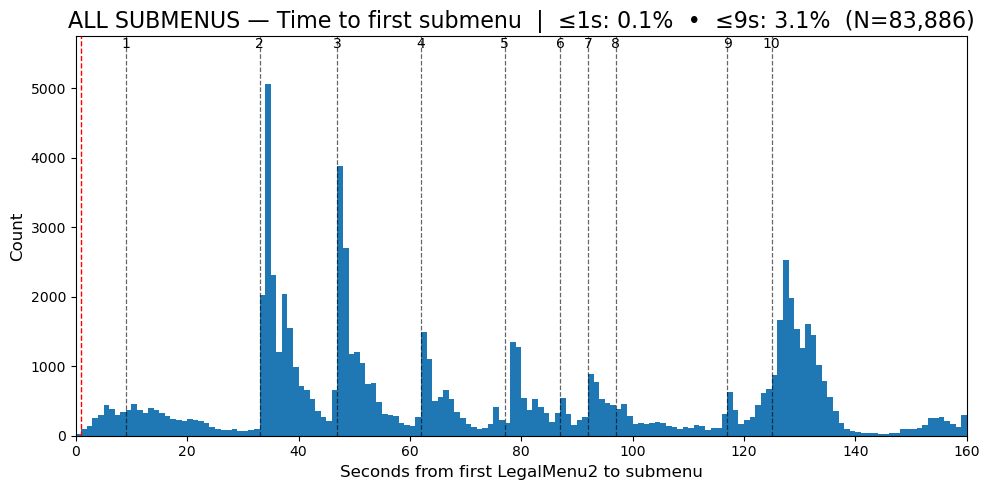

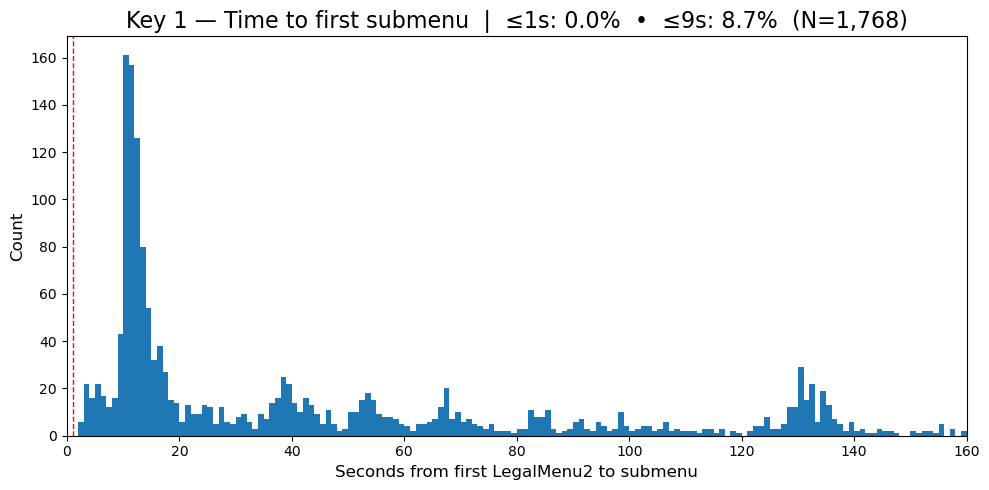

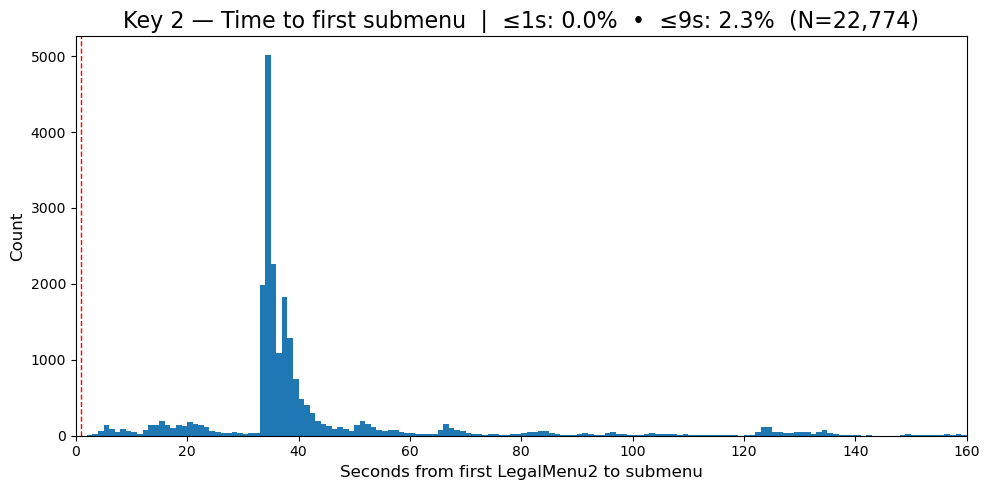

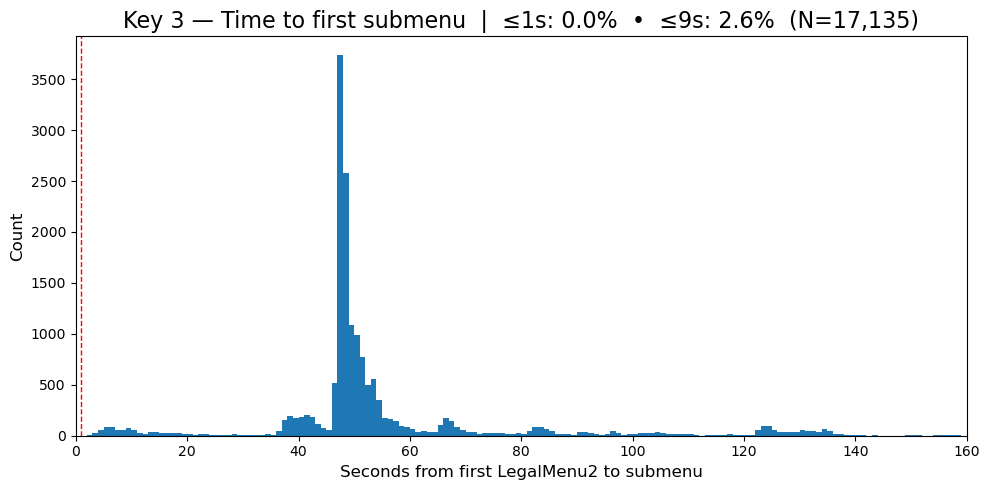

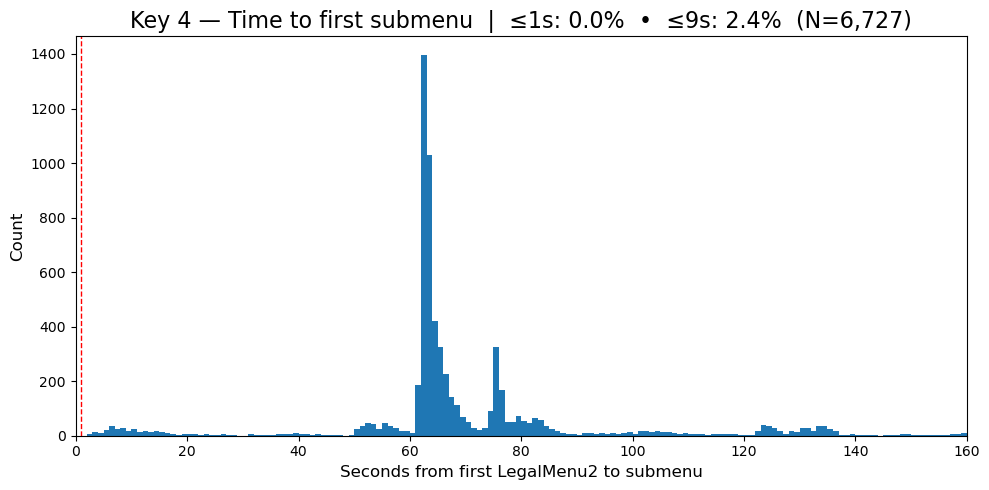

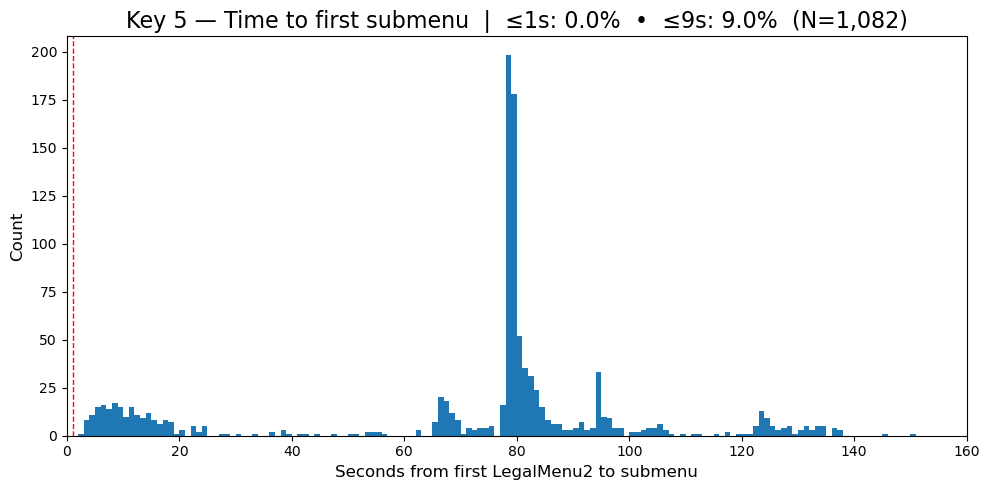

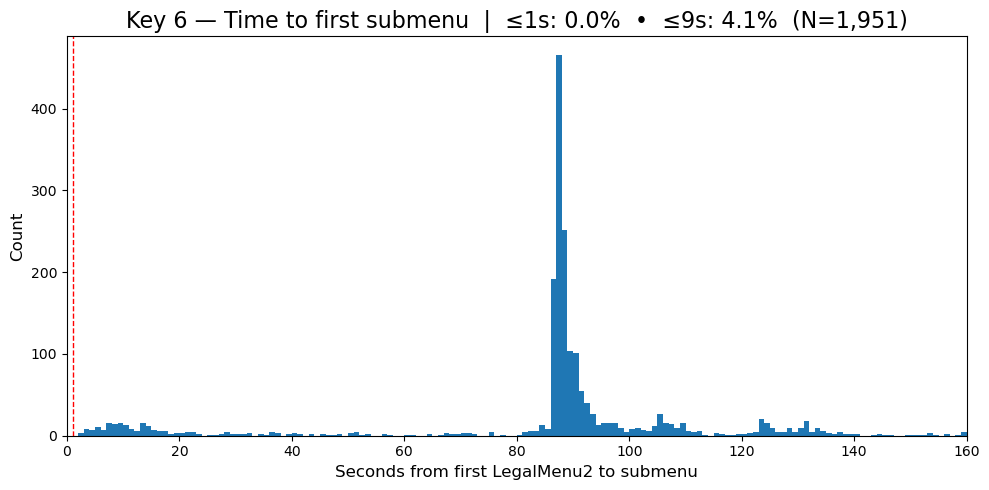

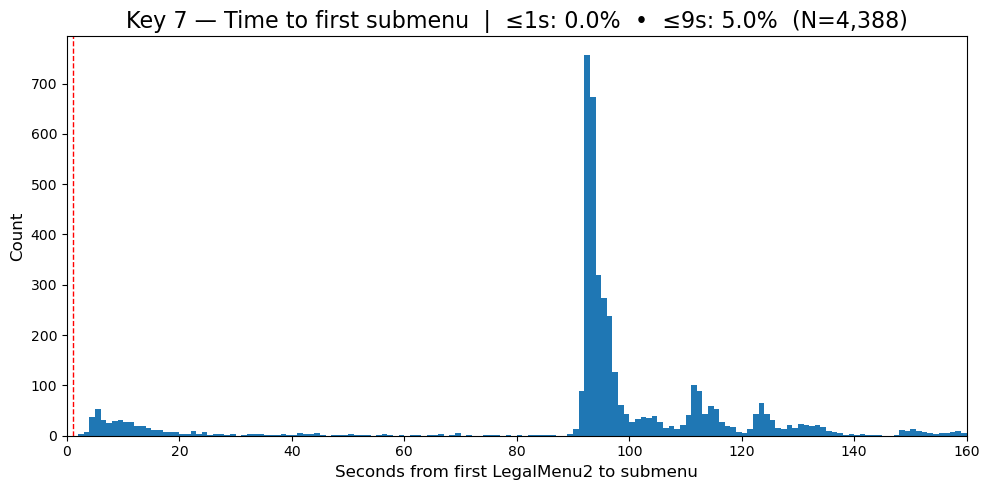

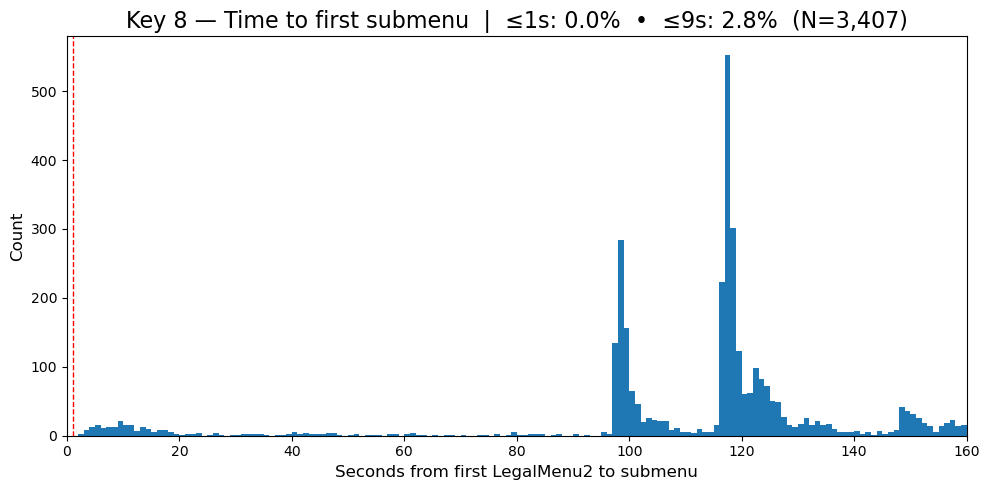

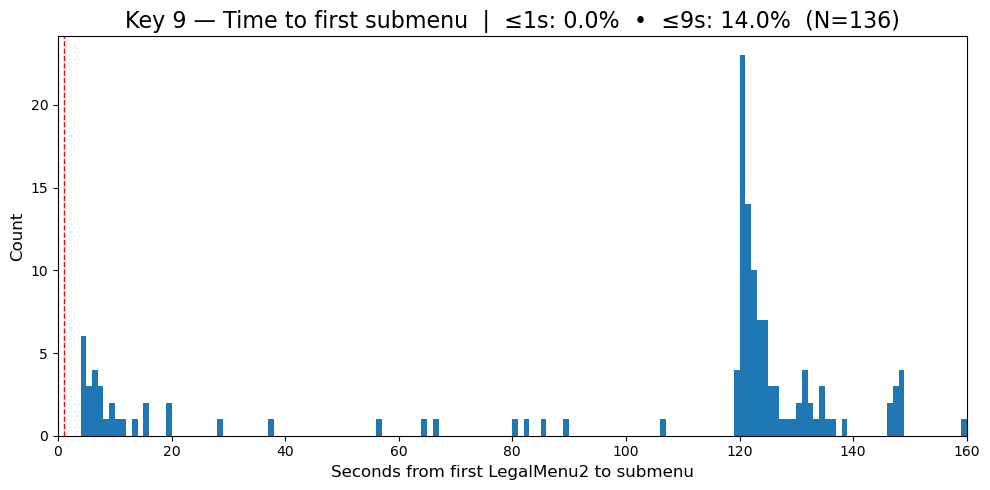

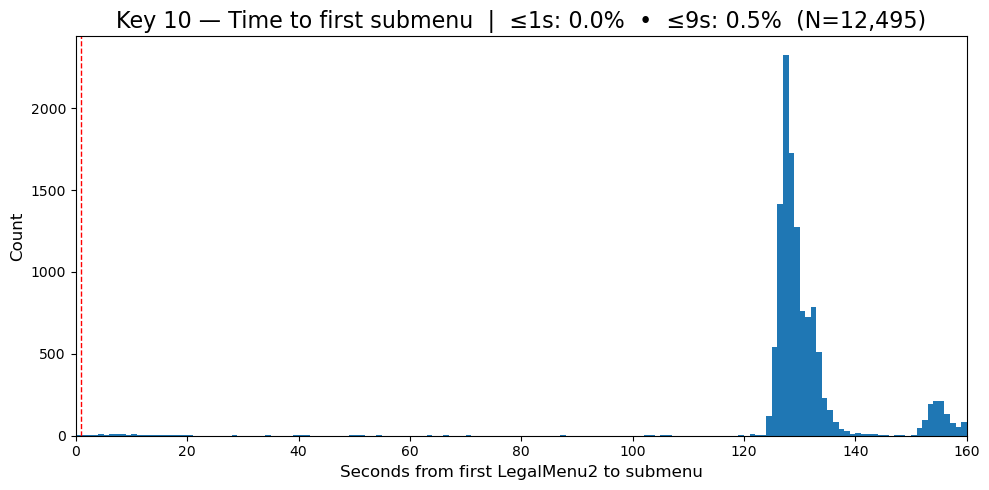

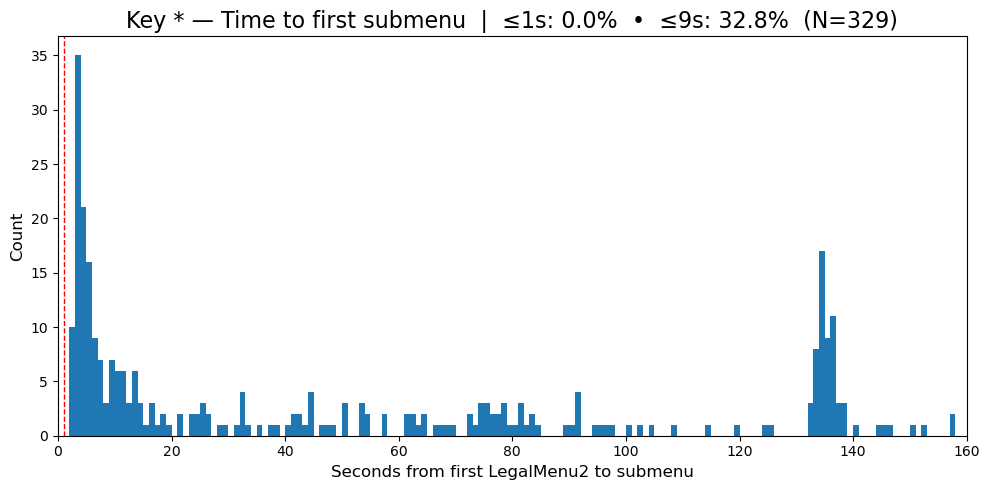

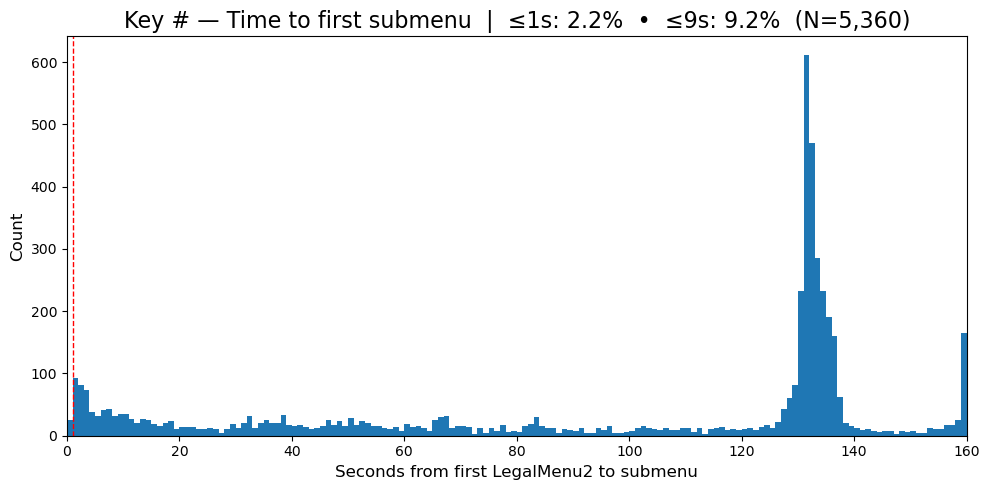

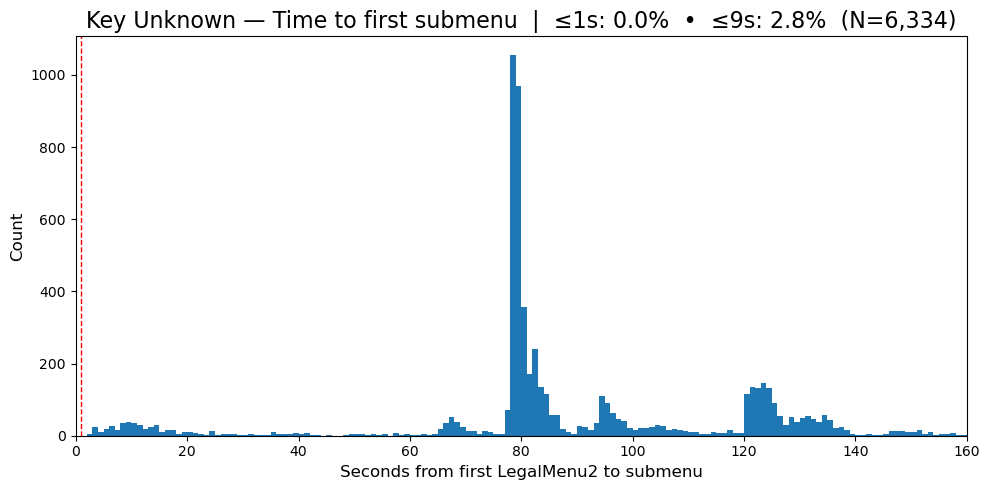

In [94]:
# ---- Map Activity Name -> legal-menu key ----
def activity_to_key(activity: object) -> str:
    if pd.isna(activity): return 'NoNextMenu'
    s = str(activity).strip().lower()
    if s == 'hivmenu': return '1'
    if s == 'familymenu': return '2'
    if s == 'housingmenu': return '3'
    if s == 'benefitsmenu': return '4'
    if s in ('getloggedinconsumeragents', 'getloggedinconsumerspagents'): return '5'
    if s == 'criminalrecordsvoicemailtransfer': return '6'
    if s == 'employmentmenu': return '7'
    if s == 'immigrationmenu': return '8'
    if s in ('getloggedinadaptagents', 'getloggedinadaptspagents'): return '9'
    if s == 'otherlegalmenu': return '10'
    if s == 'legalmenu2': return '#'
    if s in ('frontdesktransfer', 'holidayprompt'): return '*'
    return 'Unknown'

# ---- One row per session with time to first choice & which submenu ----
session = (
    df_filt[['Contact Session ID',
             'After_first_LegalMenu2_activity',
             'First_LegalMenu2_seconds_until_next']]
    .drop_duplicates(subset='Contact Session ID')
    .rename(columns={'First_LegalMenu2_seconds_until_next': 't_first_choice'})
    .copy()
)

# EXCLUDE sessions where the first LegalMenu2 visit is the last thing (no next menu)
session = session[session['After_first_LegalMenu2_activity'].notna()].copy()
session = session[session['t_first_choice'].notna()].copy()

session['After_first_key'] = session['After_first_LegalMenu2_activity'].map(activity_to_key)

# Keys to plot (exclude '#' which is the legal menu itself)
key_order = ['1','2','3','4','5','6','7','8','9','10','*','#','Unknown']

# Common bins (adjust if you want longer tails)
bins = np.arange(0, 161, 1)  # 0–60s in 1s bins


# ===== TOTAL histogram across all submenus (filtered) =====
total = session['t_first_choice']

# reference markers (seconds) to draw as dashed vertical lines
markers = [9, 33, 47, 62, 77, 87, 92, 97, 117, 125]

plt.figure(figsize=(10, 5))
plt.hist(total, bins=bins)

# red line at 1s (memorized)
ax = plt.gca()
ax.axvline(1.0, color='r', linestyle='--', linewidth=1.0, zorder=5)

# draw dashed lines + numeric labels 1..10
for i, t in enumerate(markers, start=1):
    ax.axvline(t, color='k', linestyle='--', linewidth=0.9, alpha=0.6, zorder=4)

# compute headroom and place labels near the top
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.08)  # small headroom so labels don't clip
for i, t in enumerate(markers, start=1):
    ax.text(t, ymax * 1.04, str(i), ha='center', va='bottom', fontsize=10, color='black')

# shares
share_1s = (total <= 1.0).mean() * 100 if len(total) else float("nan")
share_9s = (total <= 9.0).mean() * 100 if len(total) else float("nan")

ax.set_title(
    f"ALL SUBMENUS — Time to first submenu  |  ≤1s: {share_1s:.1f}%  •  ≤9s: {share_9s:.1f}%  (N={len(total):,})",
    fontsize=16
)
ax.set_xlabel("Seconds from first LegalMenu2 to submenu", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_xlim(bins[0], bins[-1])

plt.tight_layout()
plt.show()


# ===== Separate histogram per submenu (filtered) =====
for key in key_order:
    s = session.loc[session['After_first_key'] == key, 't_first_choice']

    plt.figure(figsize=(10, 5))
    if len(s) > 0:
        plt.hist(s, bins=bins)
        share_1s_k = (s <= 1.0).mean() * 100
        share_9s_k = (s <= 9.0).mean() * 100
        title_str = (
            f"Key {key} — Time to first submenu  |  "
            f"≤1s: {share_1s_k:.1f}%  •  ≤9s: {share_9s_k:.1f}%  (N={len(s):,})"
        )
    else:
        plt.hist([], bins=bins)
        title_str = f"Key {key} — Time to first submenu  |  ≤1s: —  •  ≤9s: —  (N=0)"

    plt.axvline(1.0, color='r', linestyle='--', linewidth=1)
    plt.title(title_str, fontsize=16)
    plt.xlabel("Seconds from first LegalMenu2 to submenu", fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.xlim(bins[0], bins[-1])
    plt.tight_layout()
    plt.show()

The 'Unknown' keys are individuals who entered a closed queue (so no indication of what key they pressed)
- However, obvious spikes for times when keys 5, 6, and 9 are recited (keys that directly lead to a queue / voicemail)

In [69]:
# One row per session with the first submenu after LegalMenu2
session_map = (
    df_filt[['Contact Session ID', 'After_first_LegalMenu2_activity']]
    .drop_duplicates(subset='Contact Session ID')
    .copy()
)

# Map to key and filter Unknown
session_map['After_first_key'] = session_map['After_first_LegalMenu2_activity'].map(activity_to_key)

unknown_sessions = session_map[session_map['After_first_key'] == 'Unknown'].copy()

# Just the caller IDs (and keep the raw activity for debugging)
unknown_callers = unknown_sessions.rename(columns={'Contact Session ID': 'caller_id'})[
    ['caller_id', 'After_first_LegalMenu2_activity']
].reset_index(drop=True)

unknown_callers.After_first_LegalMenu2_activity.value_counts()


After_first_LegalMenu2_activity
ClosedQueueMenu    6311
ClosedMenu           23
Name: count, dtype: int64

# Question 2

-  What's the breakdown of people navigating to the Other Legal Menu (key 10 from legal menu) - among the various options - personal injury, crime, etc.?
-  Cohorts of callers analyzed
     - First submenu = other legal
          - Broken down by revisit or no revisit to legal menu
     - First submenu != other legal (final submenu = other legal)
          - First submenu = family

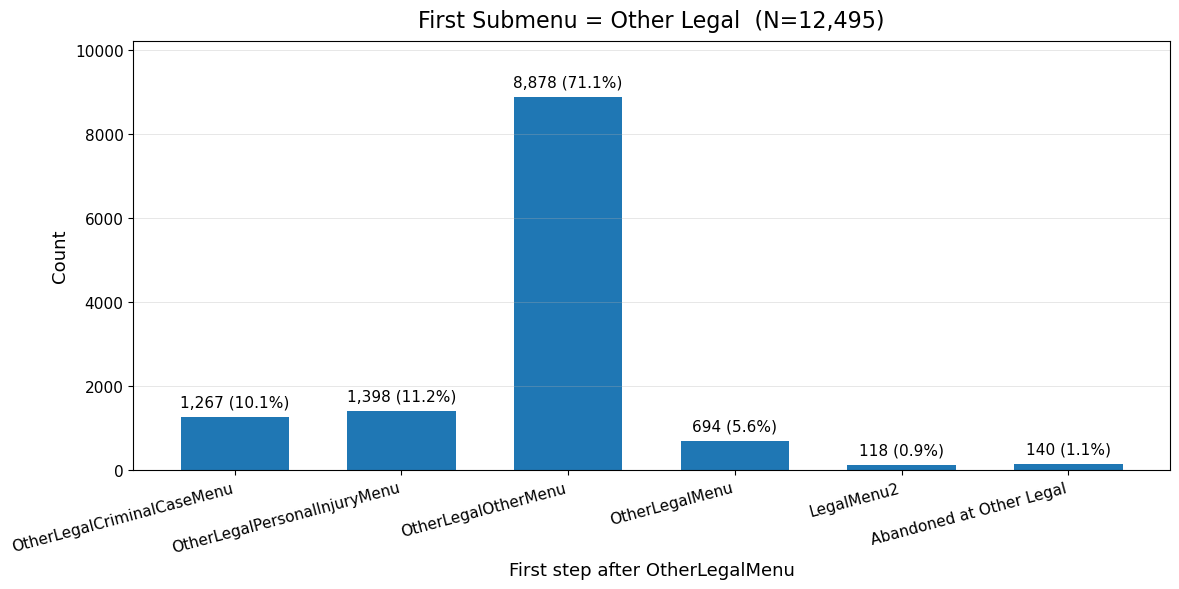

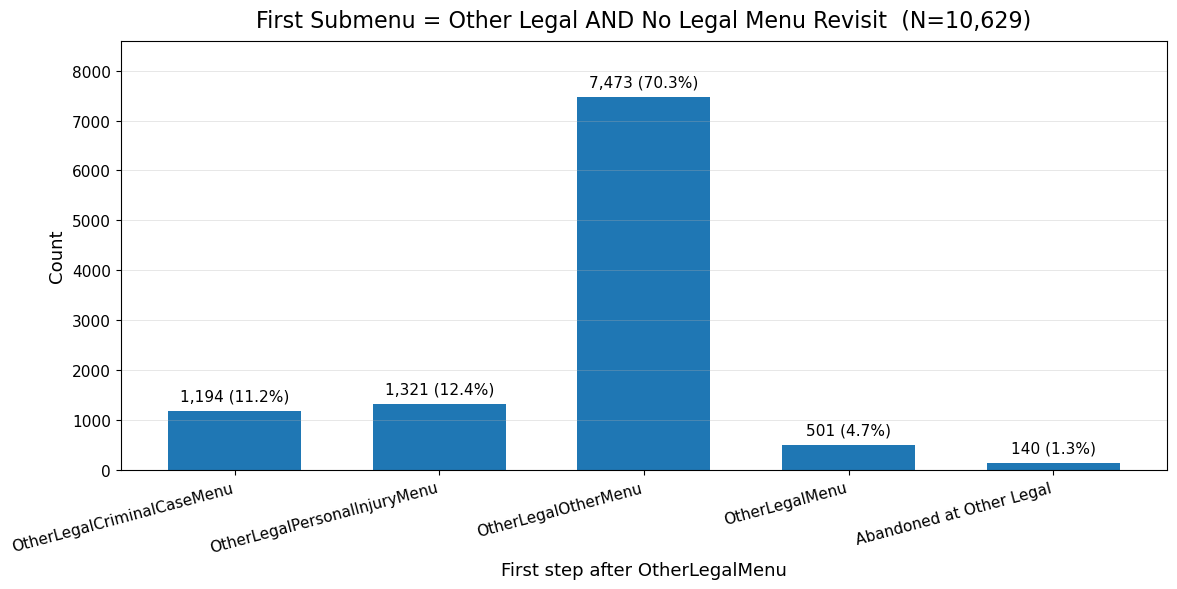

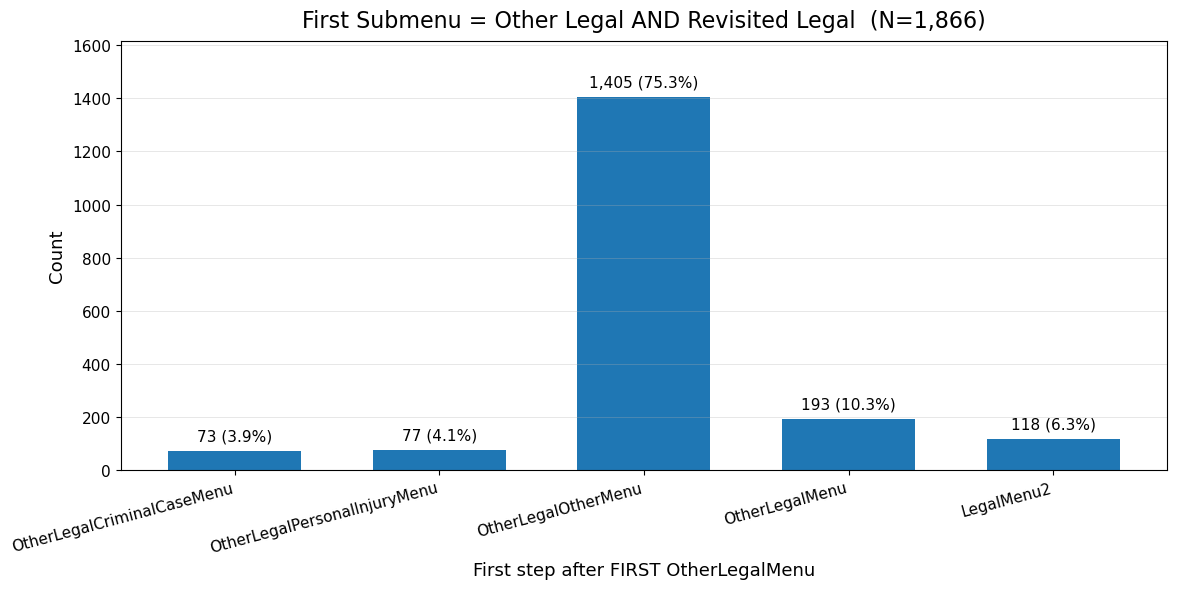

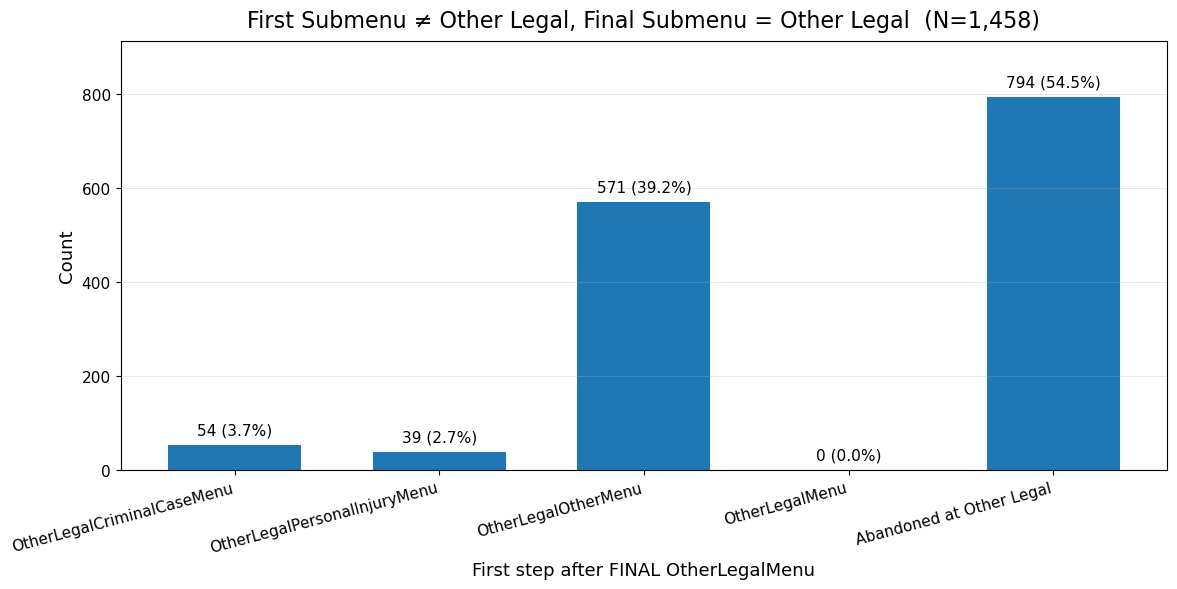

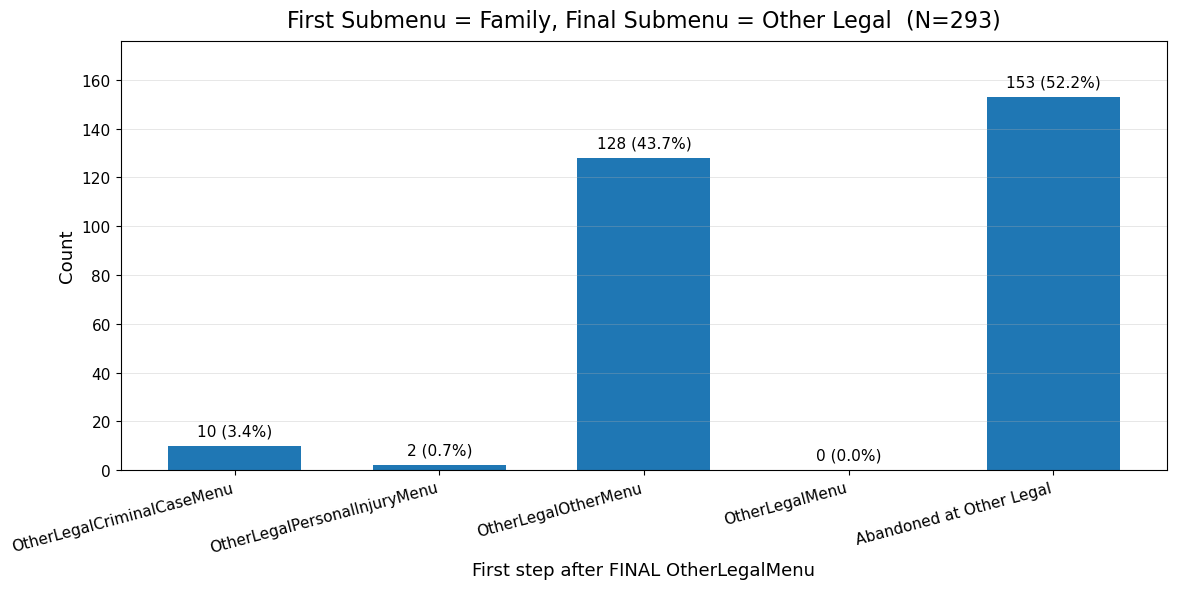

In [95]:
# ---- Row-level prep: chronologically sorted with "next activity" ----
df_s = df_filt.sort_values(['Contact Session ID', 'Activity Start Timestamp']).copy()
df_s['_next_activity'] = df_s.groupby('Contact Session ID')['Activity Name'].shift(-1)

# Tag OtherLegalMenu occurrences and their order within the session
is_olm = df_s['Activity Name'].eq('OtherLegalMenu')
df_s['_olm_ord']   = is_olm.groupby(df_s['Contact Session ID']).cumsum()
df_s['_olm_total'] = is_olm.groupby(df_s['Contact Session ID']).transform('sum')

# ---- Session-level features for cohort definitions ----
session = (
    df_filt[['Contact Session ID',
             'Num_visits',
             'After_first_LegalMenu2_activity',
             'After_final_LegalMenu2_activity']]
    .drop_duplicates('Contact Session ID')
    .copy()
)
session['After_first_key'] = session['After_first_LegalMenu2_activity'].map(activity_to_key)
session['After_final_key'] = session['After_final_LegalMenu2_activity'].map(activity_to_key)

# ---- Categories ----
FOUR = [
    'OtherLegalPersonalInjuryMenu',
    'OtherLegalCriminalCaseMenu',
    'OtherLegalOtherMenu',
    'OtherLegalMenu',  # include hub if they loop back
]
# Only Cohort A includes LegalMenu2 explicitly:
FOUR_WITH_LM2_FOR_A = FOUR + ['LegalMenu2']

E_CATS = [
    'OtherLegalCriminalCaseMenu',
    'OtherLegalPersonalInjuryMenu',
    'OtherLegalOtherMenu',
    'OtherLegalMenu',   # loop hub
    'LegalMenu2',       # straight back to legal menu
]

# ---- Generic builder ----
def build_table_for_cohort(categories, session_ids, selector: str,
                           abandoned_label: str | None = 'Abandoned at Other Legal') -> pd.DataFrame:
    tmp = df_s[
        df_s['Contact Session ID'].isin(session_ids) &
        df_s['Activity Name'].eq('OtherLegalMenu')
    ].copy()

    if selector == 'first':
        pick = tmp[tmp['_olm_ord'] == 1]
    elif selector == 'final':
        pick = tmp[tmp['_olm_ord'] == tmp['_olm_total']]
    else:
        raise ValueError("selector must be 'first' or 'final'")

    cohort_n = len(pick)
    if cohort_n == 0:
        rows = categories.copy()
        if abandoned_label is not None:
            rows += [abandoned_label]
        rows += ['Total']
        out = pd.DataFrame({'Category': rows})
        out['Count'] = 0
        out.loc[out['Category'] == 'Total', 'Count'] = 0
        out['Percent_of_cohort'] = 0.0
        out.loc[out['Category'] == 'Total', 'Percent_of_cohort'] = 100.0
        return out

    nxt = pick['_next_activity']
    cat_counts = nxt.value_counts().reindex(categories, fill_value=0)

    rows   = categories.copy()
    counts = list(cat_counts.values)

    if abandoned_label is not None:
        abandoned_count = (~nxt.isin(categories) | nxt.isna()).sum()
        rows.append(abandoned_label)
        counts.append(int(abandoned_count))

    perc = [round(c / cohort_n * 100, 1) for c in counts]
    rows.append('Total')
    counts.append(int(cohort_n))
    perc.append(100.0)

    return pd.DataFrame({'Category': rows, 'Count': counts, 'Percent_of_cohort': perc})

# ===================== Cohorts (A–D) =====================

# A) FIRST submenu after first LegalMenu2 is OtherLegalMenu (key '10') — includes LegalMenu2
cohort_A_ids = session.loc[session['After_first_key'] == '10', 'Contact Session ID']
breakdown_A_table = build_table_for_cohort(FOUR_WITH_LM2_FOR_A, cohort_A_ids, selector='first')

# B) A restricted to Num_visits == 1 — DOES NOT include LegalMenu2
cohort_B_ids = session.loc[
    (session['After_first_key'] == '10') & (session['Num_visits'] == 1),
    'Contact Session ID'
]
breakdown_B_table = build_table_for_cohort(FOUR, cohort_B_ids, selector='first')

# C) Num_visits > 1, FIRST submenu != OLM, FINAL submenu = OLM
cohort_C_ids = session.loc[
    (session['Num_visits'] > 1) &
    (session['After_first_key'] != '10') &
    (session['After_final_key'] == '10'),
    'Contact Session ID'
]
breakdown_C_table = build_table_for_cohort(FOUR, cohort_C_ids, selector='final')

# D) Same as C, but FIRST submenu = Family (key '2')
cohort_D_ids = session.loc[
    (session['Num_visits'] > 1) &
    (session['After_first_key'] == '2') &
    (session['After_final_key'] == '10'),
    'Contact Session ID'
]
breakdown_D_table = build_table_for_cohort(FOUR, cohort_D_ids, selector='final')

# ===================== Cohort (E) =====================
# E) FIRST submenu = Other Legal (key '10') AND revisited LegalMenu2 (Num_visits > 1)
cohort_E_ids = session.loc[
    (session['After_first_key'] == '10') & (session['Num_visits'] > 1),
    'Contact Session ID'
]
breakdown_E_table = build_table_for_cohort(E_CATS, cohort_E_ids, selector='first', abandoned_label=None)

# ===================== Plotting (vertical) =====================
import matplotlib.pyplot as plt
import numpy as np

def plot_cohort_table_vertical(table: pd.DataFrame, title_prefix: str, order=None, xlabel="Category"):
    if table.empty:
        print(f"{title_prefix}: no data.")
        return

    data = table[table['Category'] != 'Total'].copy()
    if order is not None:
        data['Category'] = pd.Categorical(data['Category'], categories=order, ordered=True)
        data = data.sort_values('Category')

    try:
        cohort_N = int(table.loc[table['Category'] == 'Total', 'Count'].iloc[0])
    except Exception:
        cohort_N = int(data['Count'].sum())

    cats   = data['Category'].astype(str).tolist()
    counts = data['Count'].astype(int).to_numpy()
    pcts   = data['Percent_of_cohort'].astype(float).to_numpy()

    x = np.arange(len(cats))
    width = 0.65

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(x, counts, width)

    ax.set_title(f"{title_prefix}  (N={cohort_N:,})", fontsize=16, pad=10)
    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel("Count", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(cats, rotation=15, ha='right', fontsize=11)
    ax.tick_params(axis='y', labelsize=11)
    ax.grid(axis='y', alpha=0.3, linewidth=0.7)

    ymax = counts.max() if len(counts) else 0
    ax.set_ylim(0, max(ymax * 1.15, 1))

    for rect, c, pct in zip(bars, counts, pcts):
        ax.text(
            rect.get_x() + rect.get_width()/2,
            rect.get_height() + max(0.02*ymax, 0.5),
            f"{c:,} ({pct:.1f}%)",
            ha='center',
            va='bottom',
            fontsize=11,
            color='black'
        )

    plt.tight_layout()
    plt.show()

# Plot orders
ORDER_A = [
    'OtherLegalCriminalCaseMenu',
    'OtherLegalPersonalInjuryMenu',
    'OtherLegalOtherMenu',
    'OtherLegalMenu',
    'LegalMenu2',                 # ONLY for Cohort A
    'Abandoned at Other Legal',
]
ORDER_BCD = [
    'OtherLegalCriminalCaseMenu',
    'OtherLegalPersonalInjuryMenu',
    'OtherLegalOtherMenu',
    'OtherLegalMenu',
    'Abandoned at Other Legal',
]
ORDER_E = E_CATS

# ---- Plot each cohort ----
plot_cohort_table_vertical(breakdown_A_table, "First Submenu = Other Legal", order=ORDER_A,
                           xlabel="First step after OtherLegalMenu")
plot_cohort_table_vertical(breakdown_B_table, "First Submenu = Other Legal AND No Legal Menu Revisit", order=ORDER_BCD,
                           xlabel="First step after OtherLegalMenu")
plot_cohort_table_vertical(breakdown_E_table, "First Submenu = Other Legal AND Revisited Legal", order=ORDER_E,
                           xlabel="First step after FIRST OtherLegalMenu")
plot_cohort_table_vertical(breakdown_C_table, "First Submenu ≠ Other Legal, Final Submenu = Other Legal", order=ORDER_BCD,
                           xlabel="First step after FINAL OtherLegalMenu")
plot_cohort_table_vertical(breakdown_D_table, "First Submenu = Family, Final Submenu = Other Legal", order=ORDER_BCD,
                           xlabel="First step after FINAL OtherLegalMenu")

# Question 3

- Where are people abandoning when they go to the housing menu? Is the abandonment also high for people who choose housing as the correct menu in the first choice, or only higher when housing menu is their final choice
   - Broken into two cohorts:
        - No revisits to legal menu, first submenu = housing
        - Multiple visits to legal menu, final submenu = housing

### Part I: At what part of the housing submenu do callers abandon?

In [96]:
# ---------- Prep ----------
df_s = df_filt.sort_values(['Contact Session ID', 'Activity Start Timestamp']).copy()

session = (
    df_filt[['Contact Session ID', 'Num_visits',
             'After_first_LegalMenu2_activity', 'After_final_LegalMenu2_activity']]
    .drop_duplicates('Contact Session ID')
    .copy()
)
session['After_first_key'] = session['After_first_LegalMenu2_activity'].map(activity_to_key)
session['After_final_key'] = session['After_final_LegalMenu2_activity'].map(activity_to_key)

first_housing_ts = (
    df_s.loc[df_s['Activity Name'].eq('HousingMenu'),
             ['Contact Session ID','Activity Start Timestamp']]
      .groupby('Contact Session ID')['Activity Start Timestamp'].min()
      .rename('first_housing_ts')
)
last_housing_ts = (
    df_s.loc[df_s['Activity Name'].eq('HousingMenu'),
             ['Contact Session ID','Activity Start Timestamp']]
      .groupby('Contact Session ID')['Activity Start Timestamp'].max()
      .rename('last_housing_ts')
)

df_s = df_s.merge(first_housing_ts, how='left', left_on='Contact Session ID', right_index=True)
df_s = df_s.merge(last_housing_ts,  how='left', left_on='Contact Session ID', right_index=True)

def get_session_ids(df: pd.DataFrame, mask: pd.Series) -> list:
    return df.loc[mask, 'Contact Session ID'].tolist() if 'Contact Session ID' in df.columns else df.index[mask].tolist()

def _nonempty_str(s: pd.Series) -> pd.Series:
    return s.notna() & s.astype(str).str.strip().ne('')

# ---------- CLASSIFIER (Queue + Voicemail combined) ----------
def classify_outcome_after_ref(g: pd.DataFrame, ref_ts_col: str) -> str:
    """
    Look at rows with timestamp >= ref_ts. Precedence:
      (1) Queue_or_Voicemail  [queue signal OR ClinicVoicemailTransfer/ClosedMenu]
      (2) If 'Customer Left' present, classify by last non-null Activity *before* that row
          if it is one of: HousingMenu, PreTenantMenu, TenantMenu, TenantDeterrenceMenu
      (3) Else classify by last non-null Activity into the 4 housing menus, else 'Other'
    """
    ref_ts = g[ref_ts_col].iloc[0]
    if pd.isna(ref_ts):
        return 'Other'
    g2 = g[g['Activity Start Timestamp'] >= ref_ts]
    if g2.empty:
        return 'Other'

    # (1) Queue_or_Voicemail
    queue_signal = (
        g2['Activity Name'].astype(str).str.contains('queue', case=False, na=False)
        | _nonempty_str(g2['Queue Name'])
        | _nonempty_str(g2['Agent Name'])
    )
    voicemail_signal = g2['Activity Name'].isin(['ClinicVoicemailTransfer', 'ClosedMenu'])
    if queue_signal.any() or voicemail_signal.any():
        return 'Queue_or_Voicemail'

    # Helper: last non-null Activity before the first 'Customer Left'
    last_four = ('HousingMenu', 'PreTenantMenu', 'TenantMenu', 'TenantDeterrenceMenu')
    if 'Termination Reason' in g2.columns:
        tr_norm = g2['Termination Reason'].astype(str).str.strip().str.lower()
        idxs = np.where((tr_norm == 'customer left').values)[0]
        if len(idxs) > 0:
            pos = idxs[0]  # first 'Customer Left'
            before = g2.iloc[:pos]
            if not before.empty:
                prev_nonnull = before['Activity Name'].dropna()
                if len(prev_nonnull) > 0:
                    last_before = prev_nonnull.iloc[-1]
                    if last_before in last_four:
                        return last_before

    # (3) Fallback: last non-null Activity bucket
    tail_nonnull = g2['Activity Name'].dropna()
    if len(tail_nonnull) == 0:
        return 'Other'
    last_act = tail_nonnull.iloc[-1]
    return last_act if last_act in last_four else 'Other'

ORDER = [
    'Queue_or_Voicemail',
    'HousingMenu',
    'PreTenantMenu',
    'TenantMenu',
    'TenantDeterrenceMenu',
    'Other'
]

def summarize_outcomes(outcomes: pd.Series) -> pd.DataFrame:
    # Ensure all outcomes are strings; drop NaNs if any slipped through
    outcomes = outcomes.astype('object').dropna().astype(str)

    ORDER = [
        'Queue_or_Voicemail',
        'HousingMenu',
        'PreTenantMenu',
        'TenantMenu',
        'TenantDeterrenceMenu',
        'Other'
    ]

    counts = outcomes.value_counts().reindex(ORDER, fill_value=0).astype(int)
    total = int(counts.sum())

    if total > 0:
        pct = (counts / total * 100).round(2)
    else:
        pct = pd.Series(0.0, index=counts.index, dtype=float)

    out = pd.DataFrame({
        'Outcome': counts.index,
        'Count': counts.values,
        'Percent': pct.values,
        'Total_N': total
    })
    return out


# ---------- Cohort 1: single legal visit & first submenu = Housing ----------
mask1 = (session['Num_visits'] == 1) & (session['After_first_key'] == '3')
cohort1_ids = get_session_ids(session, mask1)

if len(cohort1_ids) == 0:
    cohort1_summary = pd.DataFrame({'Outcome': ORDER, 'Count': 0, 'Percent': 0.0, 'Total_N': 0})
else:
    sub1 = df_s[df_s['Contact Session ID'].isin(cohort1_ids) & df_s['first_housing_ts'].notna()].copy()
    outcomes1 = sub1.groupby('Contact Session ID', as_index=True)\
                    .apply(lambda g: classify_outcome_after_ref(g, 'first_housing_ts'))
    cohort1_summary = summarize_outcomes(outcomes1)

# ---------- Cohort 2: multiple legal visits & final submenu = Housing ----------
mask2 = (session['Num_visits'] > 1) & (session['After_final_key'] == '3')
cohort2_ids = get_session_ids(session, mask2)

if len(cohort2_ids) == 0:
    cohort2_summary = pd.DataFrame({'Outcome': ORDER, 'Count': 0, 'Percent': 0.0, 'Total_N': 0})
else:
    sub2 = df_s[df_s['Contact Session ID'].isin(cohort2_ids) & df_s['last_housing_ts'].notna()].copy()
    outcomes2 = sub2.groupby('Contact Session ID', as_index=True)\
                    .apply(lambda g: classify_outcome_after_ref(g, 'last_housing_ts'))
    cohort2_summary = summarize_outcomes(outcomes2)

# ---------- Results ----------
print("\n=== Cohort 1 — First submenu = Housing, single legal visit (Num_visits == 1) ===")
print(cohort1_summary)

print("\n=== Cohort 2 — Final submenu = Housing, multiple legal visits (Num_visits > 1) ===")
print(cohort2_summary)



=== Cohort 1 — First submenu = Housing, single legal visit (Num_visits == 1) ===
                Outcome  Count  Percent  Total_N
0    Queue_or_Voicemail  10546    72.49    14549
1           HousingMenu    693     4.76    14549
2         PreTenantMenu    444     3.05    14549
3            TenantMenu   2082    14.31    14549
4  TenantDeterrenceMenu    784     5.39    14549
5                 Other      0     0.00    14549

=== Cohort 2 — Final submenu = Housing, multiple legal visits (Num_visits > 1) ===
                Outcome  Count  Percent  Total_N
0    Queue_or_Voicemail   1467    70.56     2079
1           HousingMenu    142     6.83     2079
2         PreTenantMenu     72     3.46     2079
3            TenantMenu    301    14.48     2079
4  TenantDeterrenceMenu     97     4.67     2079
5                 Other      0     0.00     2079


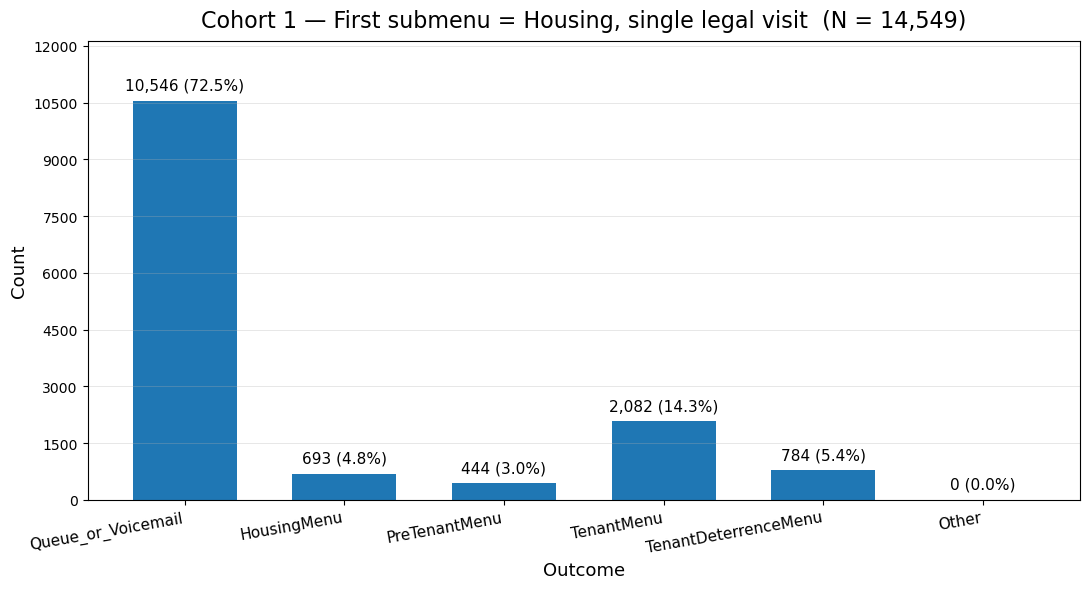

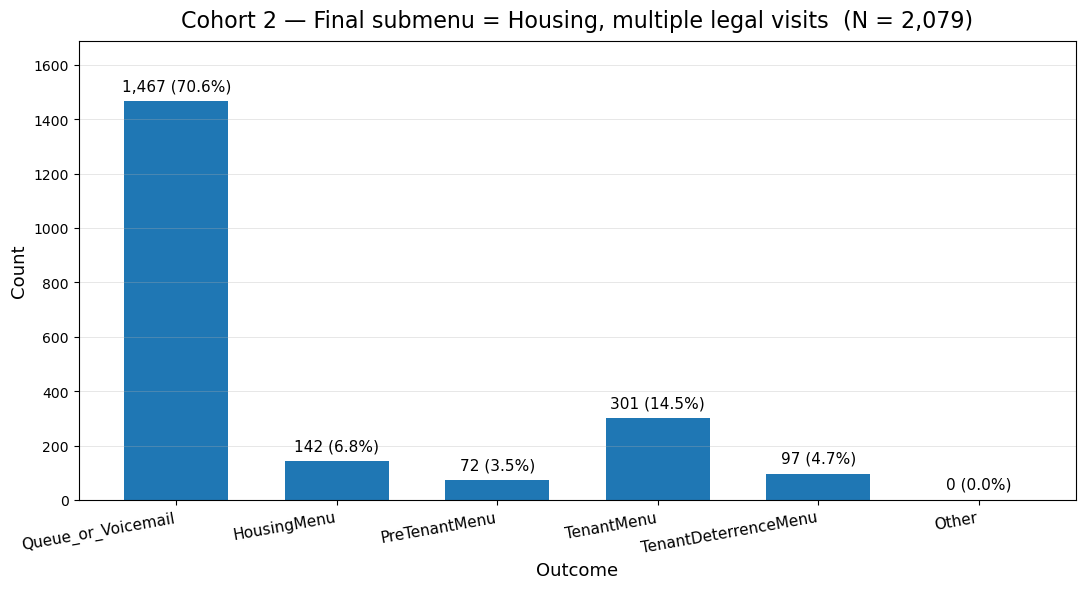

In [97]:
from matplotlib.ticker import MaxNLocator
# Desired order (same as in your tables)
ORDER = [
    'Queue_or_Voicemail',
    'HousingMenu',
    'PreTenantMenu',
    'TenantMenu',
    'TenantDeterrenceMenu',
    'Other'
]

def plot_summary(df, title_prefix):
    # Guard for empty or missing columns
    if df is None or df.empty or not {'Outcome','Count','Percent','Total_N'}.issubset(df.columns):
        print(f"{title_prefix}: no data to plot.")
        return

    # Enforce order & fill missing categories with zeros
    plot_df = (
        df.set_index('Outcome')
          .reindex(ORDER, fill_value=0)
          .reset_index()
    )

    x = range(len(plot_df))
    counts = plot_df['Count'].astype(int).values
    pcts   = plot_df['Percent'].astype(float).values
    totalN = int(plot_df['Total_N'].max())  # same for all rows

    fig, ax = plt.subplots(figsize=(11, 6))
    bars = ax.bar(x, counts, width=0.65)

    ax.set_title(f"{title_prefix}  (N = {totalN:,})", fontsize=16, pad=10)
    ax.set_xlabel("Outcome", fontsize=13)
    ax.set_ylabel("Count", fontsize=13)
    ax.set_xticks(list(x))
    ax.set_xticklabels(plot_df['Outcome'], rotation=10, ha='right', fontsize=11)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(axis='y', alpha=0.3, linewidth=0.7)

    # Headroom so labels fit
    ymax = max(counts) if len(counts) else 0
    ax.set_ylim(0, max(1, int(ymax * 1.15 + 1)))

    # Labels above bars: "count (pct%)"
    for rect, c, pct in zip(bars, counts, pcts):
        ax.text(rect.get_x() + rect.get_width()/2,
                rect.get_height() + max(0.02*ymax, 0.5),
                f"{c:,} ({pct:.1f}%)",
                ha='center', va='bottom', fontsize=11, color='black')

    plt.tight_layout()
    plt.show()

# --- Plot both cohorts ---
plot_summary(cohort1_summary, "Cohort 1 — First submenu = Housing, single legal visit")
plot_summary(cohort2_summary, "Cohort 2 — Final submenu = Housing, multiple legal visits")


### Part II: How deep do callers get in the housing submenu?

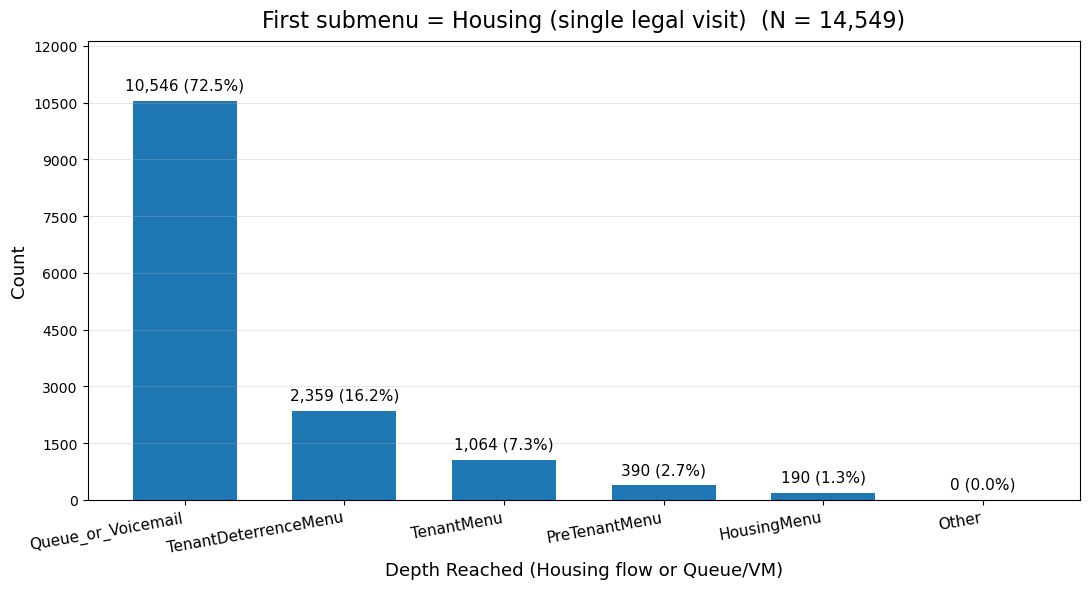

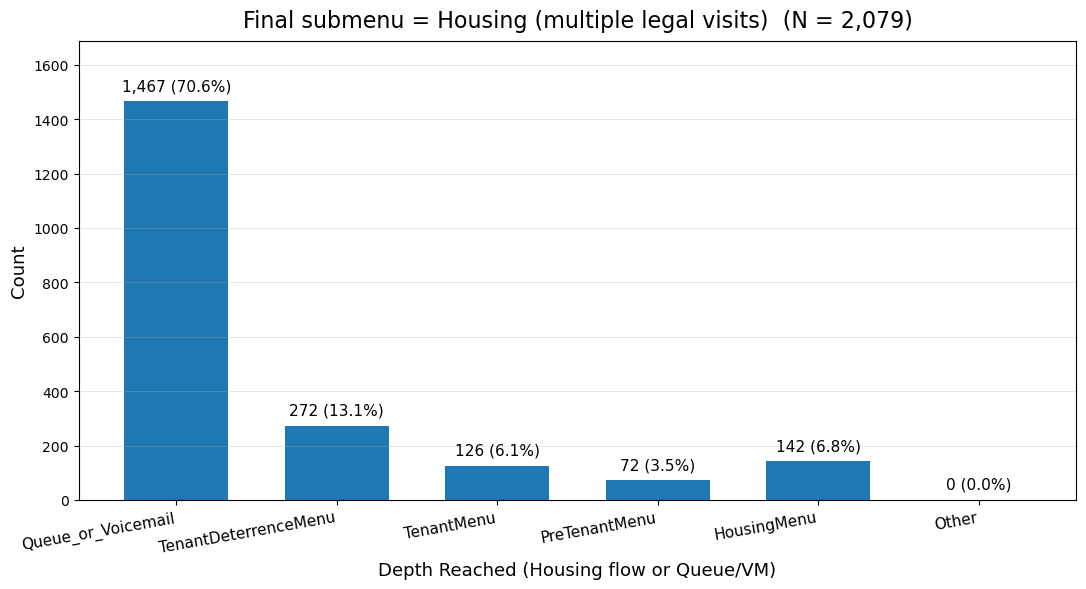

In [98]:
# ========== Prep ==========
df_s = df_filt.sort_values(['Contact Session ID', 'Activity Start Timestamp']).copy()

session = (
    df_filt[['Contact Session ID','Num_visits',
             'After_first_LegalMenu2_activity','After_final_LegalMenu2_activity']]
      .drop_duplicates('Contact Session ID')
      .copy()
)
session['After_first_key'] = session['After_first_LegalMenu2_activity'].map(activity_to_key)
session['After_final_key'] = session['After_final_LegalMenu2_activity'].map(activity_to_key)

# First & last time each session enters HousingMenu
first_housing_ts = (
    df_s.loc[df_s['Activity Name'].eq('HousingMenu'),
             ['Contact Session ID','Activity Start Timestamp']]
      .groupby('Contact Session ID')['Activity Start Timestamp'].min()
      .rename('first_housing_ts')
)
last_housing_ts = (
    df_s.loc[df_s['Activity Name'].eq('HousingMenu'),
             ['Contact Session ID','Activity Start Timestamp']]
      .groupby('Contact Session ID')['Activity Start Timestamp'].max()
      .rename('last_housing_ts')
)

df_s = df_s.merge(first_housing_ts, how='left', left_on='Contact Session ID', right_index=True)
df_s = df_s.merge(last_housing_ts,  how='left', left_on='Contact Session ID', right_index=True)

def get_session_ids(df: pd.DataFrame, mask: pd.Series) -> list:
    return df.loc[mask, 'Contact Session ID'].tolist() if 'Contact Session ID' in df.columns else df.index[mask].tolist()

def _nonempty_str(s: pd.Series) -> pd.Series:
    return s.notna() & s.astype(str).str.strip().ne('')

# ========== CLASSIFIER (Depth reached in housing) ==========
def classify_depth_after_ref(g: pd.DataFrame, ref_ts_col: str) -> str:
    """
    Look at rows with timestamp >= ref_ts for one session. Precedence:
      (1) Queue_or_Voicemail  [queue signal OR ClinicVoicemailTransfer/ClosedMenu]
      (2) TenantDeterrenceMenu (if appears anywhere after ref)
      (3) TenantMenu
      (4) PreTenantMenu
      (5) HousingMenu  (fallback; assume reached since ref is set off HousingMenu)
      (6) Other (safety fallback)
    """
    ref_ts = g[ref_ts_col].iloc[0]
    if pd.isna(ref_ts):
        return 'Other'
    g2 = g[g['Activity Start Timestamp'] >= ref_ts]
    if g2.empty:
        return 'Other'

    # (1) Queue or Voicemail
    queue_signal = (
        g2['Activity Name'].astype(str).str.contains('queue', case=False, na=False)
        | _nonempty_str(g2['Queue Name'])
        | _nonempty_str(g2['Agent Name'])
    )
    voicemail_signal = g2['Activity Name'].isin(['ClinicVoicemailTransfer', 'ClosedMenu'])
    if queue_signal.any() or voicemail_signal.any():
        return 'Queue_or_Voicemail'

    # (2)-(5) Depth within housing flow
    if (g2['Activity Name'] == 'TenantDeterrenceMenu').any():
        return 'TenantDeterrenceMenu'
    if (g2['Activity Name'] == 'TenantMenu').any():
        return 'TenantMenu'
    if (g2['Activity Name'] == 'PreTenantMenu').any():
        return 'PreTenantMenu'
    if (g2['Activity Name'] == 'HousingMenu').any():
        return 'HousingMenu'

    return 'Other'

ORDER = [
    'Queue_or_Voicemail',
    'TenantDeterrenceMenu',
    'TenantMenu',
    'PreTenantMenu',
    'HousingMenu',
    'Other'
]

def summarize_outcomes(outcomes: pd.Series) -> pd.DataFrame:
    # Safe against NaNs
    outcomes = outcomes.astype('object').dropna().astype(str)
    counts = outcomes.value_counts().reindex(ORDER, fill_value=0).astype(int)
    total = int(counts.sum())
    pct = (counts / total * 100).round(1) if total > 0 else pd.Series(0.0, index=counts.index, dtype=float)
    out = pd.DataFrame({'Outcome': counts.index,
                        'Count': counts.values,
                        'Percent': pct.values,
                        'Total_N': total})
    return out

# ========== Cohorts ==========
# Cohort 1: single legal visit & first submenu = Housing
mask1 = (session['Num_visits'] == 1) & (session['After_first_key'] == '3')
cohort1_ids = get_session_ids(session, mask1)

if len(cohort1_ids) == 0:
    cohort1_summary = pd.DataFrame({'Outcome': ORDER, 'Count': 0, 'Percent': 0.0, 'Total_N': 0})
else:
    sub1 = df_s[df_s['Contact Session ID'].isin(cohort1_ids) & df_s['first_housing_ts'].notna()].copy()
    outcomes1 = sub1.groupby('Contact Session ID', as_index=True)\
                    .apply(lambda g: classify_depth_after_ref(g, 'first_housing_ts'))
    cohort1_summary = summarize_outcomes(outcomes1)

# Cohort 2: multiple legal visits & final submenu = Housing
mask2 = (session['Num_visits'] > 1) & (session['After_final_key'] == '3')
cohort2_ids = get_session_ids(session, mask2)

if len(cohort2_ids) == 0:
    cohort2_summary = pd.DataFrame({'Outcome': ORDER, 'Count': 0, 'Percent': 0.0, 'Total_N': 0})
else:
    sub2 = df_s[df_s['Contact Session ID'].isin(cohort2_ids) & df_s['last_housing_ts'].notna()].copy()
    outcomes2 = sub2.groupby('Contact Session ID', as_index=True)\
                    .apply(lambda g: classify_depth_after_ref(g, 'last_housing_ts'))
    cohort2_summary = summarize_outcomes(outcomes2)

# ========== Visualization ==========
def plot_summary(df, title_prefix):
    if df is None or df.empty or not {'Outcome','Count','Percent','Total_N'}.issubset(df.columns):
        print(f"{title_prefix}: no data to plot.")
        return
    plot_df = df.set_index('Outcome').reindex(ORDER, fill_value=0).reset_index()
    x = range(len(plot_df))
    counts = plot_df['Count'].astype(int).values
    pcts   = plot_df['Percent'].astype(float).values
    totalN = int(plot_df['Total_N'].max())

    fig, ax = plt.subplots(figsize=(11, 6))
    bars = ax.bar(x, counts, width=0.65)
    ax.set_title(f"{title_prefix}  (N = {totalN:,})", fontsize=16, pad=10)
    ax.set_xlabel("Depth Reached (Housing flow or Queue/VM)", fontsize=13)
    ax.set_ylabel("Count", fontsize=13)
    ax.set_xticks(list(x))
    ax.set_xticklabels(plot_df['Outcome'], rotation=10, ha='right', fontsize=11)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(axis='y', alpha=0.3, linewidth=0.7)

    ymax = max(counts) if len(counts) else 0
    ax.set_ylim(0, max(1, int(ymax * 1.15 + 1)))

    for rect, c, pct in zip(bars, counts, pcts):
        ax.text(rect.get_x() + rect.get_width()/2,
                rect.get_height() + max(0.02*ymax, 0.5),
                f"{c:,} ({pct:.1f}%)",
                ha='center', va='bottom', fontsize=11, color='black')

    plt.tight_layout()
    plt.show()

# Plot both cohorts
plot_summary(cohort1_summary, "First submenu = Housing (single legal visit)")
plot_summary(cohort2_summary, "Final submenu = Housing (multiple legal visits)")


- Among callers who revisited the legal menu
- Also including the percent of successful calls and reaching a queue for aech submenu visited after a final Legal Menu visit
- To clarify, there is a count and percent success graph for each submenu visited first

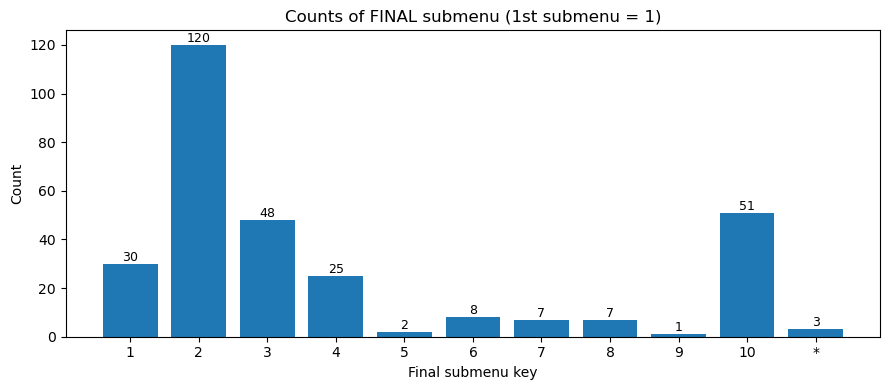

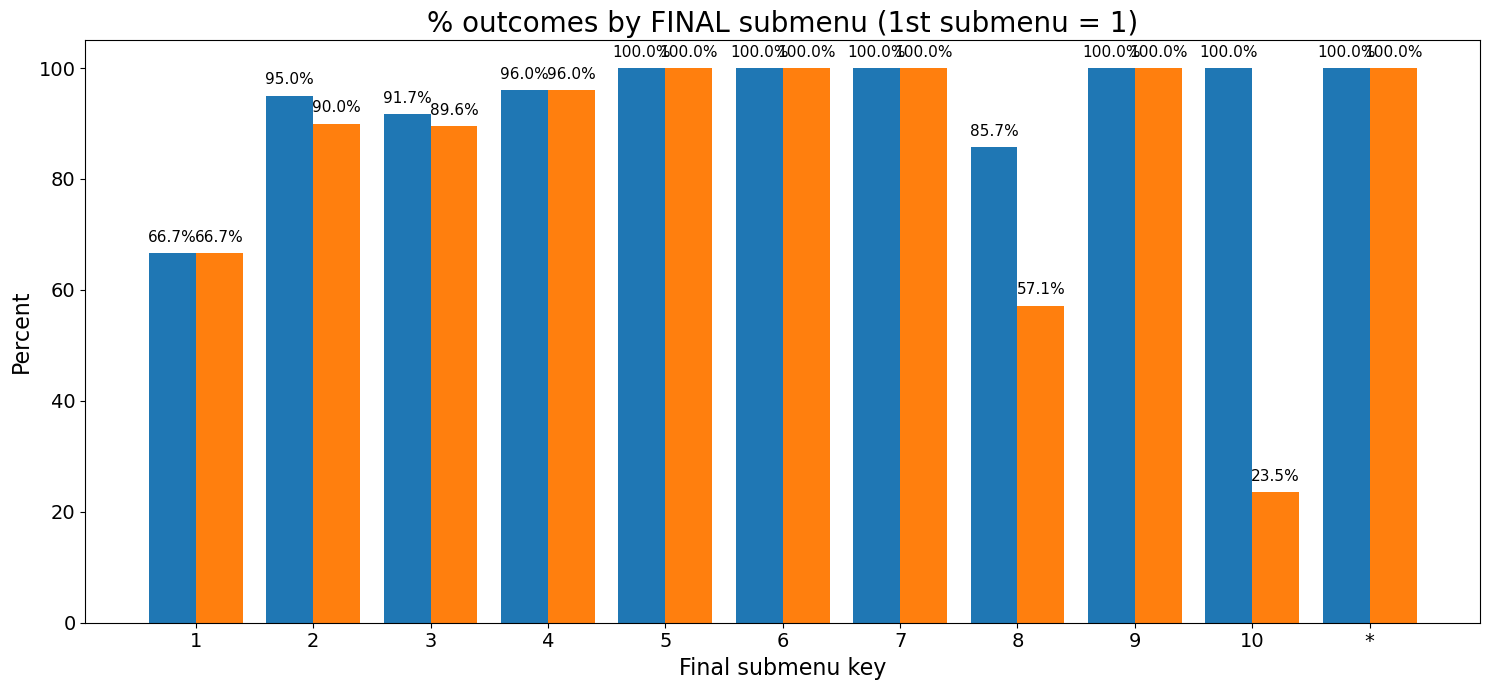

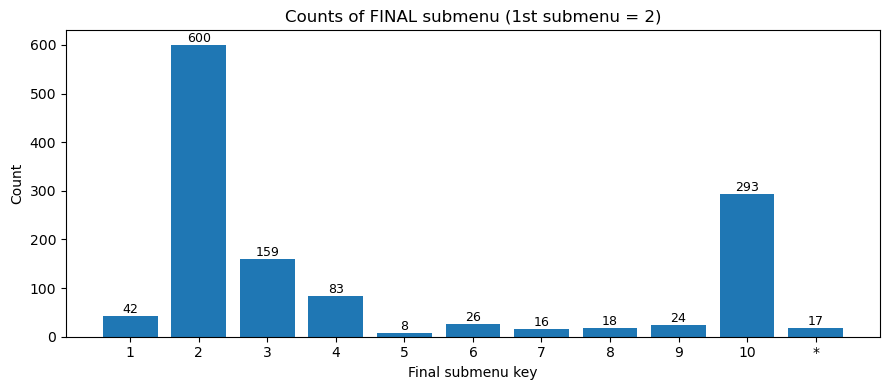

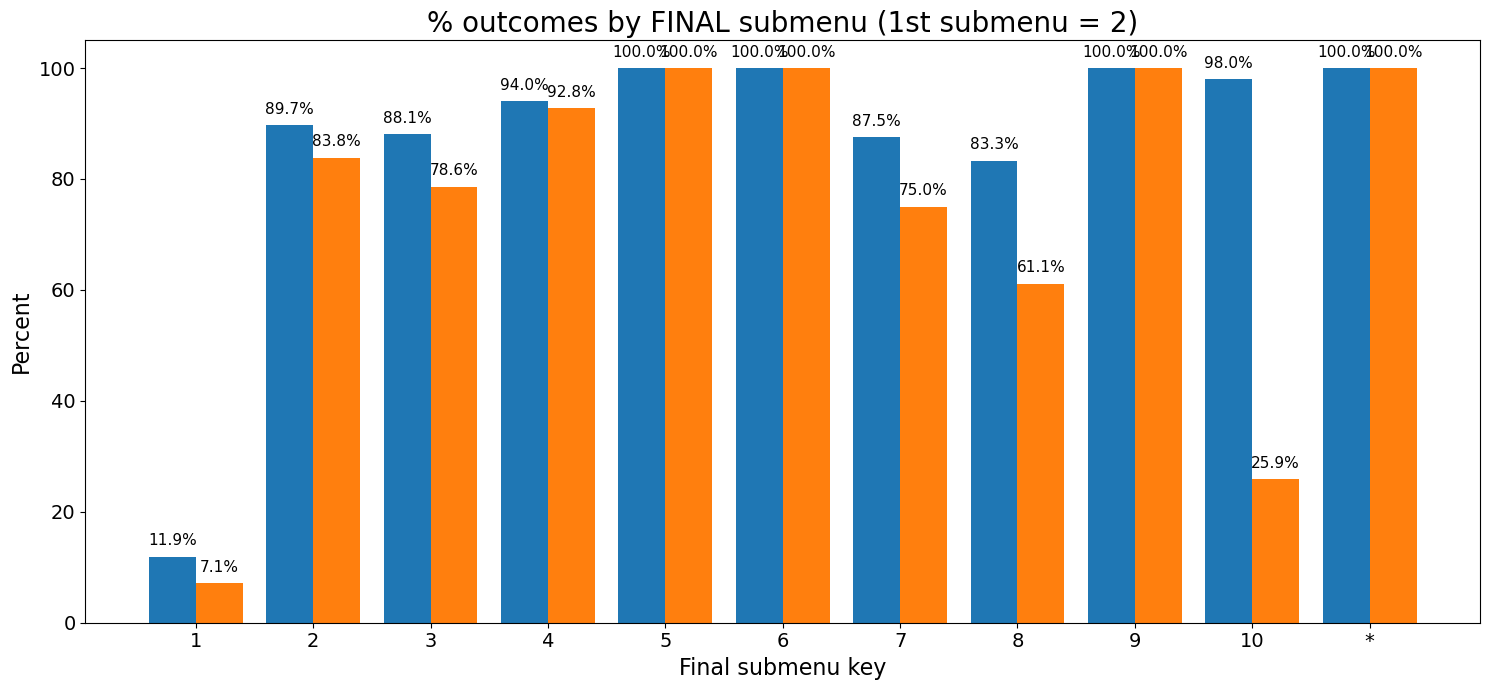

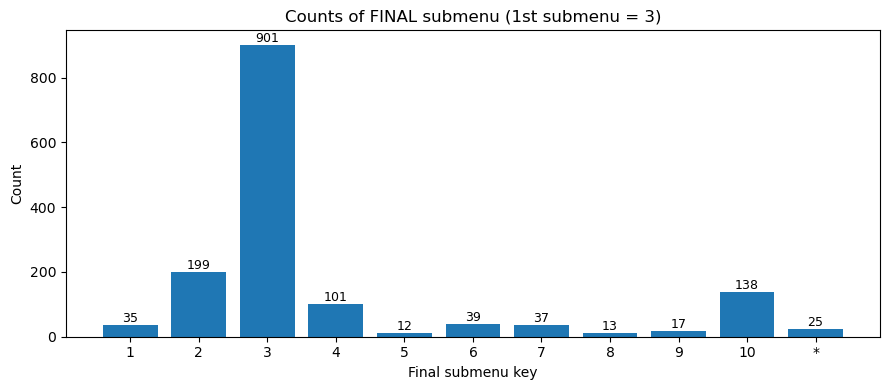

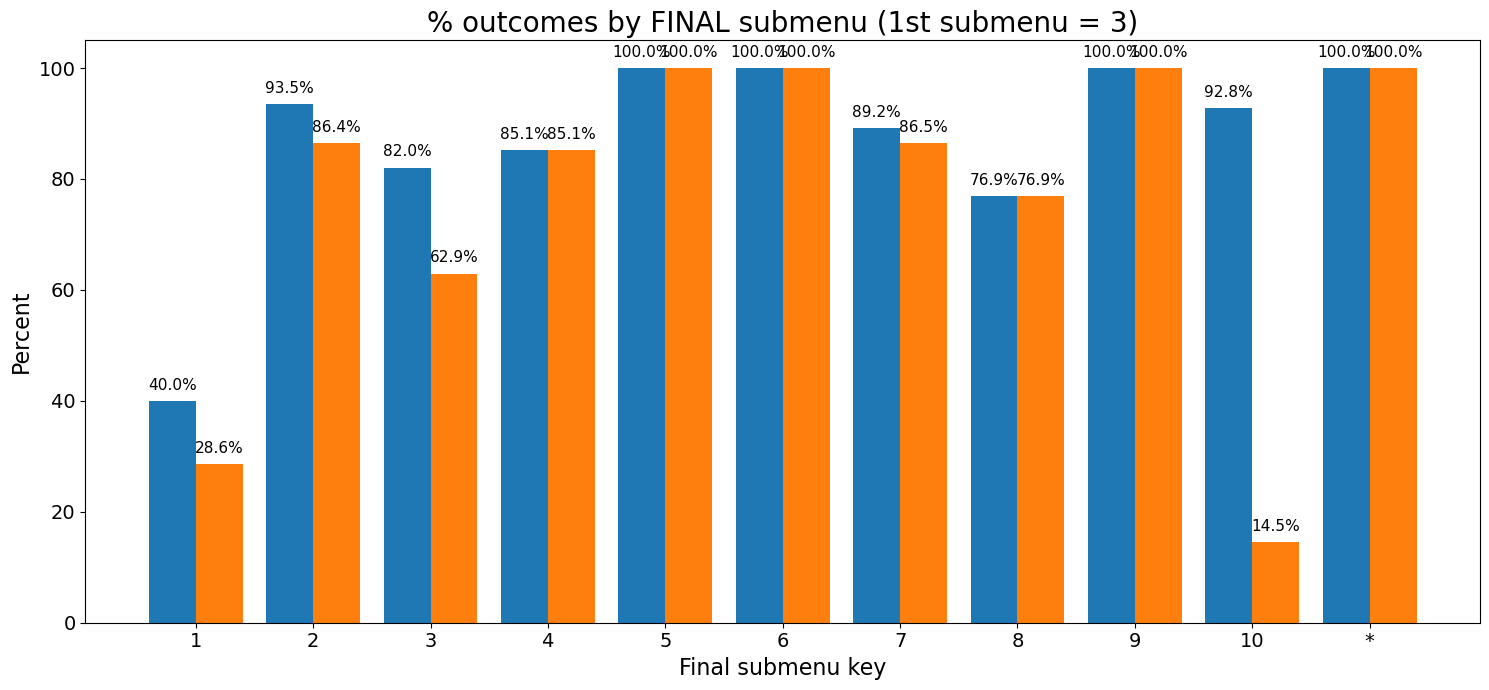

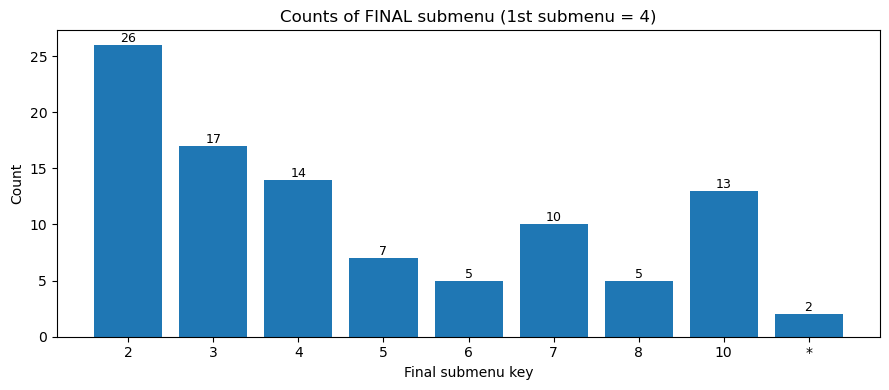

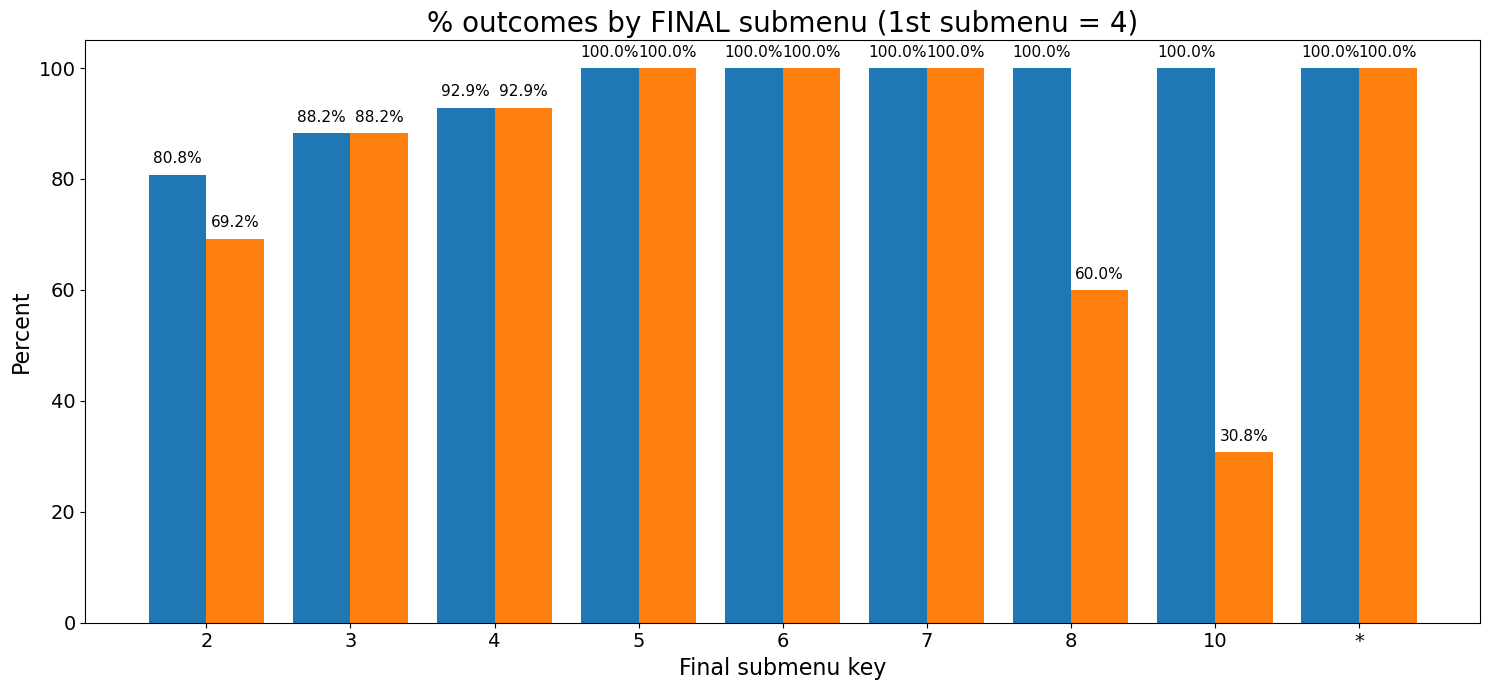

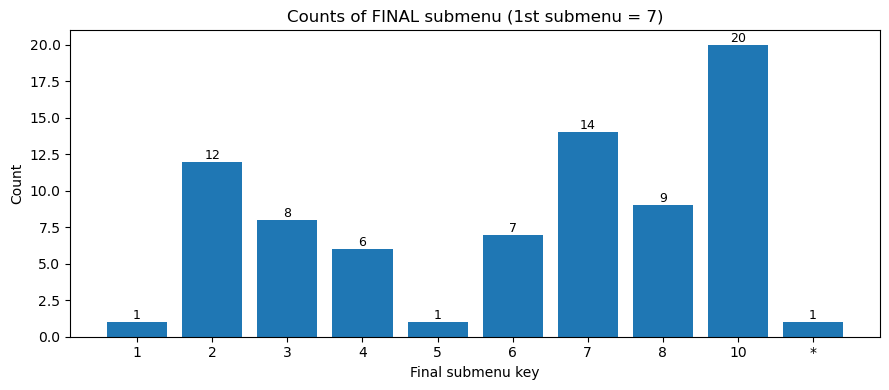

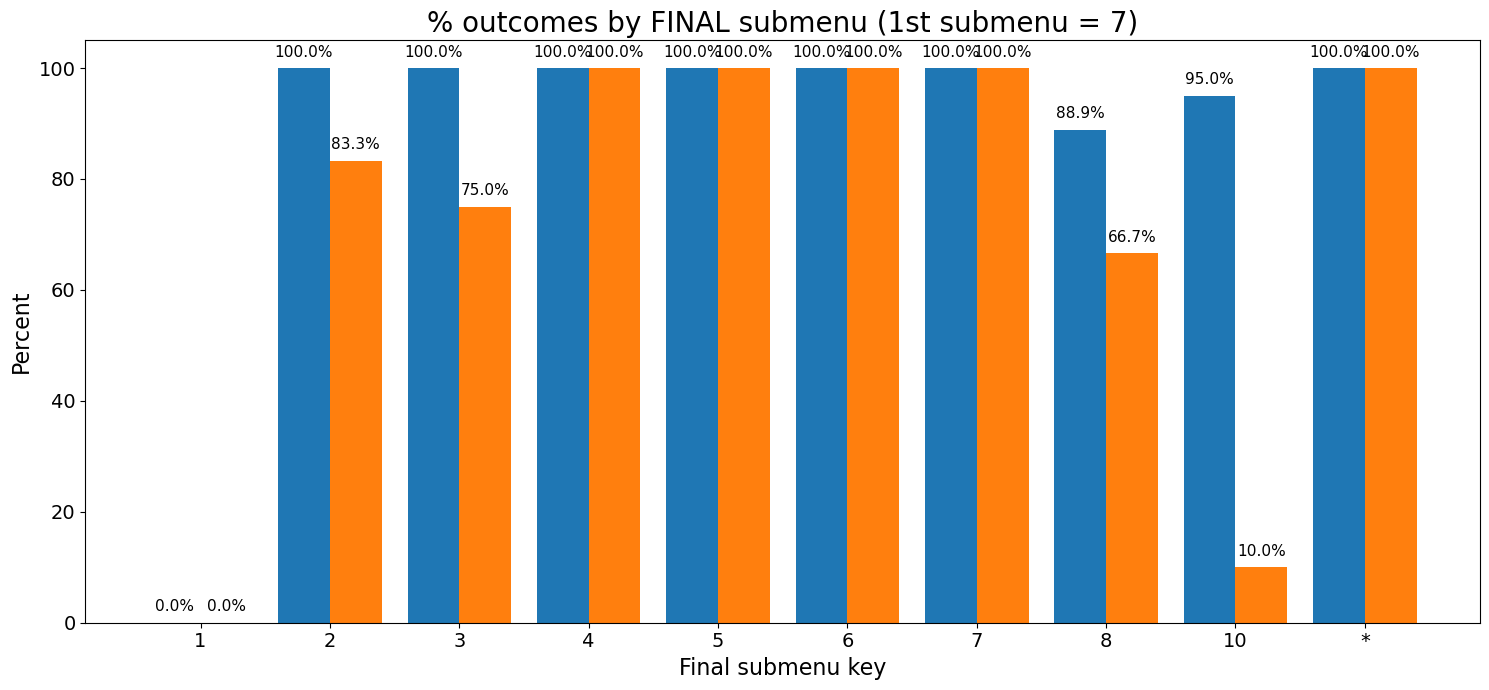

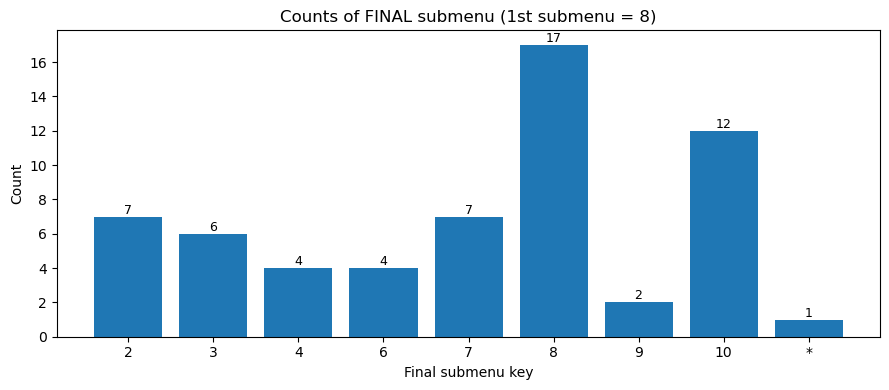

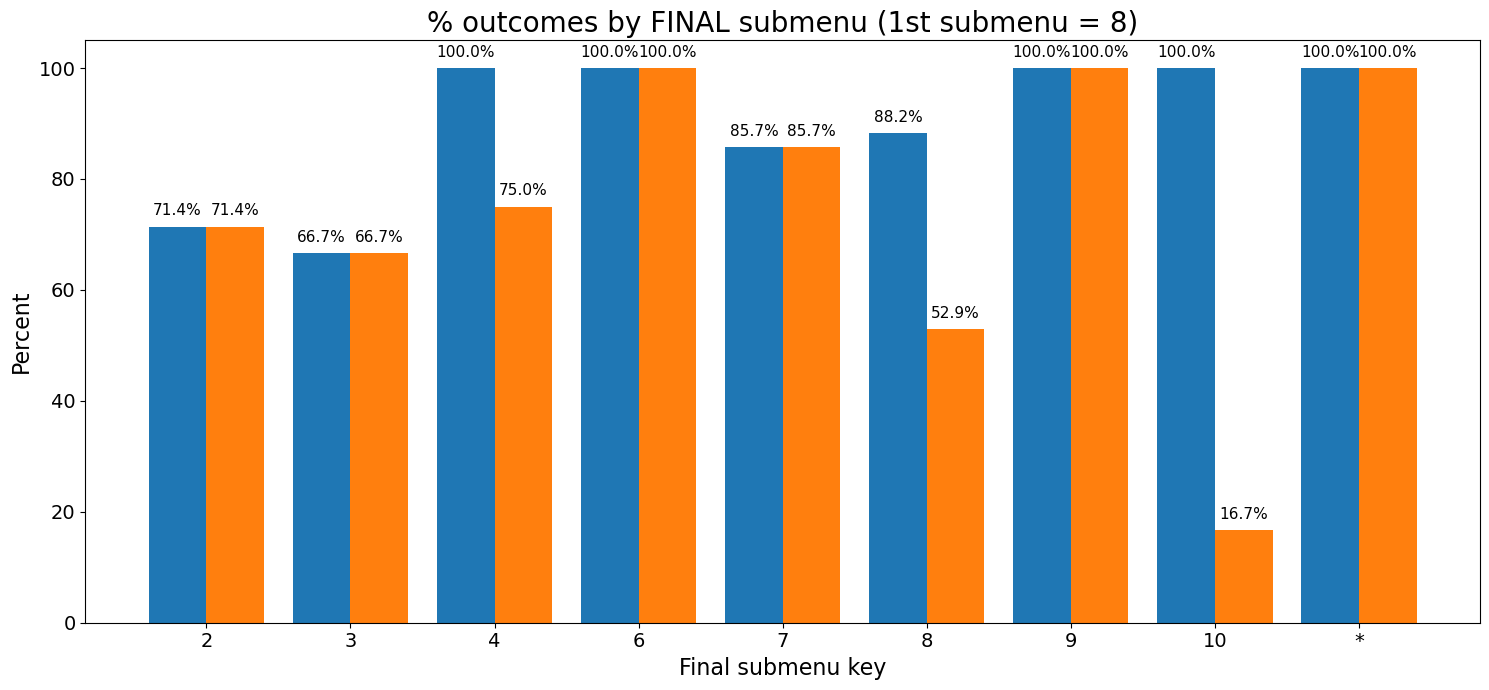

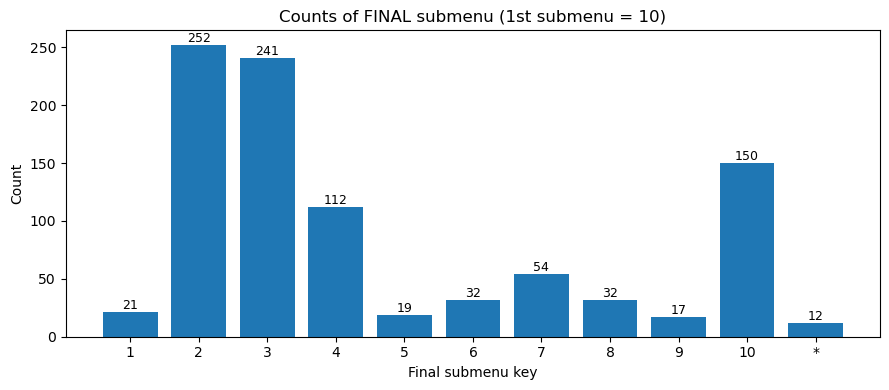

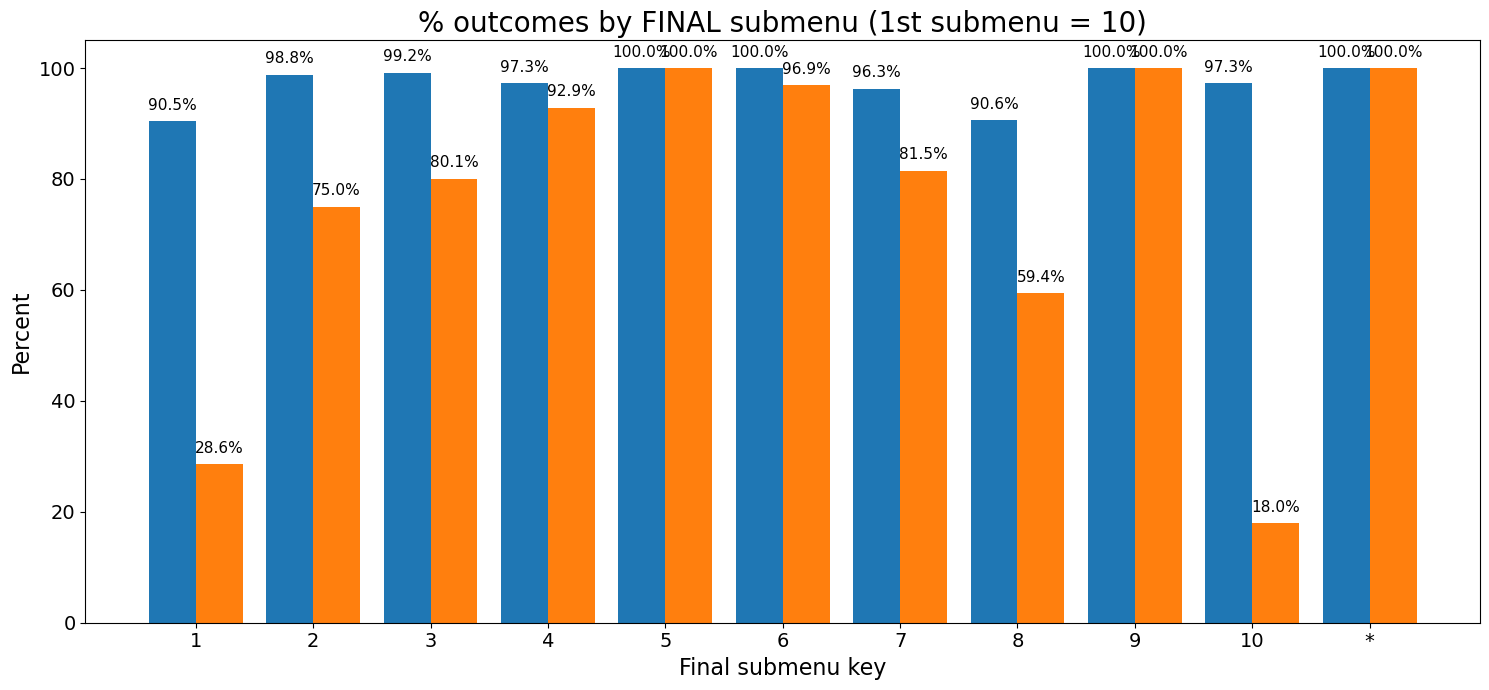

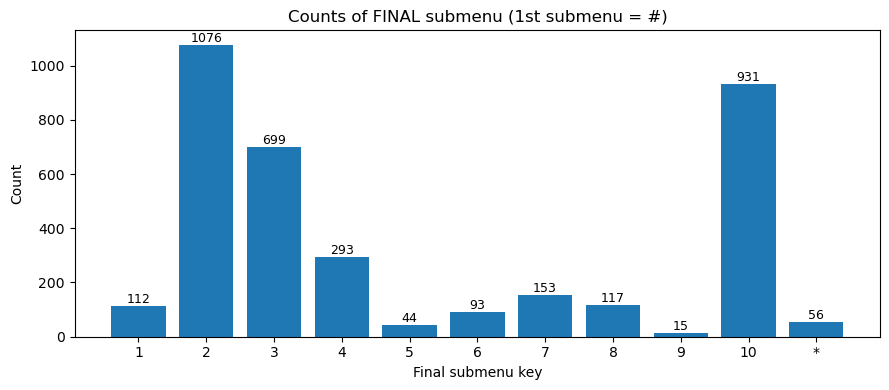

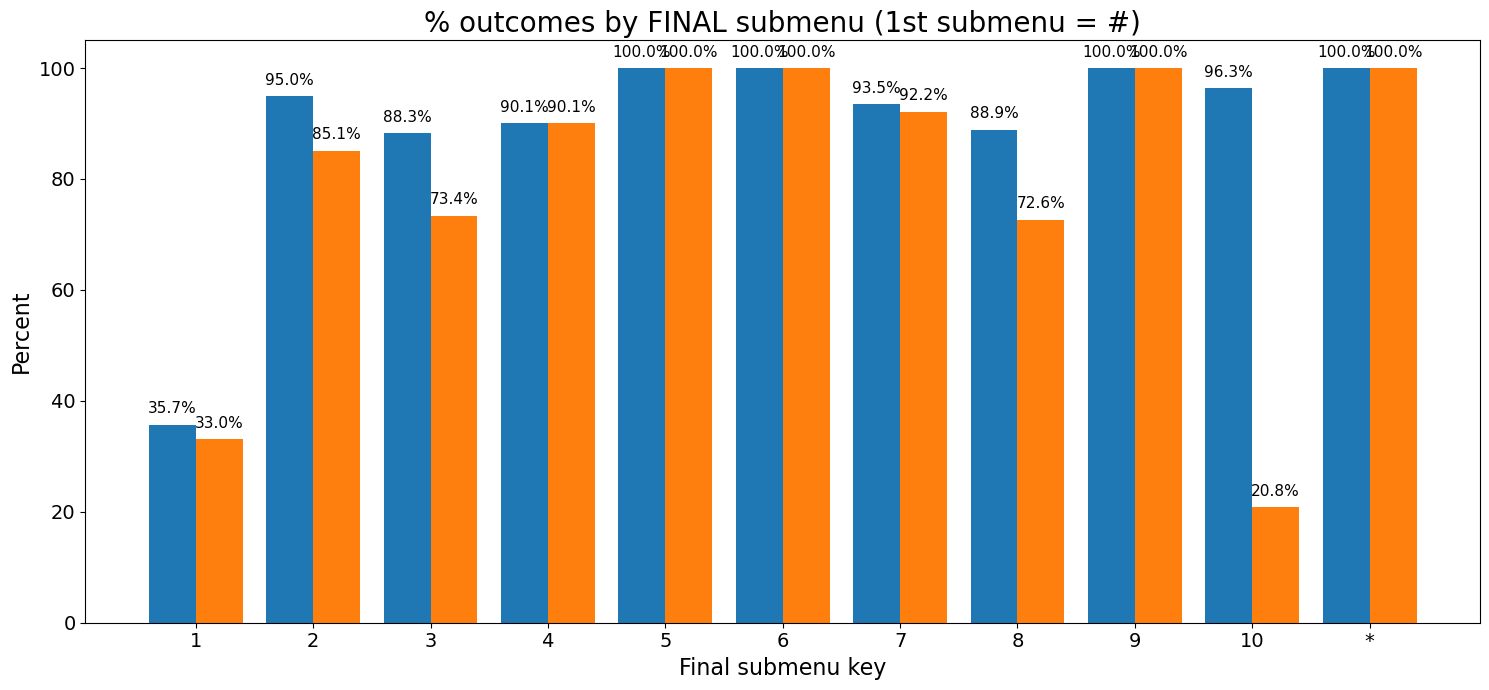

In [7]:
key_to_submenus = {
    '1':  'HIVMenu',
    '2':  'FamilyMenu',
    '3':  'HousingMenu',
    '4':  'BenefitsMenu',
    '5':  'GetLoggedInConsumerAgents | GetLoggedInConsumerSPAgents',
    '6':  'CriminalRecordsVoicemailTransfer',
    '7':  'EmploymentMenu',
    '8':  'ImmigrationMenu',
    '9':  'GetLoggedInADAPTAgents | GetLoggedInADAPTSPAgents',
    '10': 'OtherLegalMenu',
    '#':  'LegalMenu2',
    '*':  'FrontDeskTransfer | HolidayPrompt',
    'NoNextMenu': '—',
    'Unknown':    '—',
}

def activity_to_key(activity: object) -> str:
    if pd.isna(activity): return 'NoNextMenu'
    s = str(activity).strip().lower()
    if s == 'hivmenu': return '1'
    if s == 'familymenu': return '2'
    if s == 'housingmenu': return '3'
    if s == 'benefitsmenu': return '4'
    if s in ('getloggedinconsumeragents', 'getloggedinconsumerspagents'): return '5'
    if s == 'criminalrecordsvoicemailtransfer': return '6'
    if s == 'employmentmenu': return '7'
    if s == 'immigrationmenu': return '8'
    if s in ('getloggedinadaptagents', 'getloggedinadaptspagents'): return '9'
    if s == 'otherlegalmenu': return '10'
    if s == 'legalmenu2': return '#'
    if s in ('frontdesktransfer', 'holidayprompt'): return '*'
    return 'Unknown'

# 1) one row per session
session_df = (
    df_filt[['Contact Session ID',
             'After_first_LegalMenu2_activity',
             'After_final_LegalMenu2_activity',
             'Call_successful',
             'Reached_queue',
             'Num_visits']]
    .drop_duplicates(subset='Contact Session ID')
    .copy()
)

# 2) keep ONLY sessions that revisited the legal menu
session_df = session_df[session_df['Num_visits'] > 1].copy()

session_df['After_first_key'] = session_df['After_first_LegalMenu2_activity'].map(activity_to_key)
session_df['After_final_key'] = session_df['After_final_LegalMenu2_activity'].map(activity_to_key)

# only sessions that actually have a final submenu
session_df = session_df[
    session_df['After_final_key'].notna()
    & (session_df['After_final_key'] != 'NoNextMenu')
    & (session_df['After_final_key'] != 'Unknown')
].copy()

x_order = ['1','2','3','4','5','6','7','8','9','10','#','*']
first_keys = ['1','2','3','4','5','6','7','8','9','10','#','*']

for k in first_keys:
    sub = session_df[session_df['After_first_key'] == k]
    if sub.empty:
        continue

    # --- Plot 1: counts of FINAL submenu ---
    counts = (
        sub['After_final_key']
        .value_counts()
        .reindex(x_order)
        .fillna(0)
        .astype(int)
    )
    mask = counts > 0
    plot_keys   = counts.index[mask]
    plot_counts = counts[mask]

    plt.figure(figsize=(9, 4))
    bars = plt.bar(range(len(plot_counts)), plot_counts.values)
    plt.title(f"Counts of FINAL submenu (1st submenu = {k})")
    plt.xlabel("Final submenu key")
    plt.ylabel("Count")
    plt.xticks(range(len(plot_counts)), plot_keys, ha='center', rotation=0)
    for r, v in zip(bars, plot_counts.values):
        plt.text(r.get_x() + r.get_width()/2, r.get_height(),
                 f"{int(v)}", ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

    # --- Plot 2: % Call_successful vs % Reached_queue (wide, no legend) ---
    grp = sub.groupby('After_final_key')
    pct_success = (grp['Call_successful'].mean() * 100).reindex(x_order)
    pct_queue   = (grp['Reached_queue'].mean()   * 100).reindex(x_order)
    
    pct_success = pct_success[mask]
    pct_queue   = pct_queue[mask]
    
    x = np.arange(len(plot_keys))
    bar_width = 0.4
    
    fig, ax = plt.subplots(figsize=(15, 7))
    b1 = ax.bar(x - bar_width/2, pct_success.values, bar_width, color='C0')
    b2 = ax.bar(x + bar_width/2, pct_queue.values,   bar_width, color='C1')
    
    ax.set_title(f"% outcomes by FINAL submenu (1st submenu = {k})", fontsize=20)
    ax.set_xlabel("Final submenu key", fontsize=16)
    ax.set_ylabel("Percent", fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_keys, ha='center', rotation=0, fontsize=14)
    ax.tick_params(axis='y', labelsize=14)
    
    max_pct = max(pct_success.max(), pct_queue.max())
    ax.set_ylim(0, min(105, max_pct + 5))
    
    # labels ABOVE bars, black
    for r, v in zip(b1, pct_success.values):
        ax.text(
            r.get_x() + r.get_width()/2,
            r.get_height() + 1.5,     # a little above the bar
            f"{v:.1f}%",
            ha='center',
            va='bottom',
            fontsize=11,
            color='black'
        )
    
    for r, v in zip(b2, pct_queue.values):
        ax.text(
            r.get_x() + r.get_width()/2,
            r.get_height() + 1.5,
            f"{v:.1f}%",
            ha='center',
            va='bottom',
            fontsize=11,
            color='black'
        )
    
    fig.tight_layout()
    plt.show()



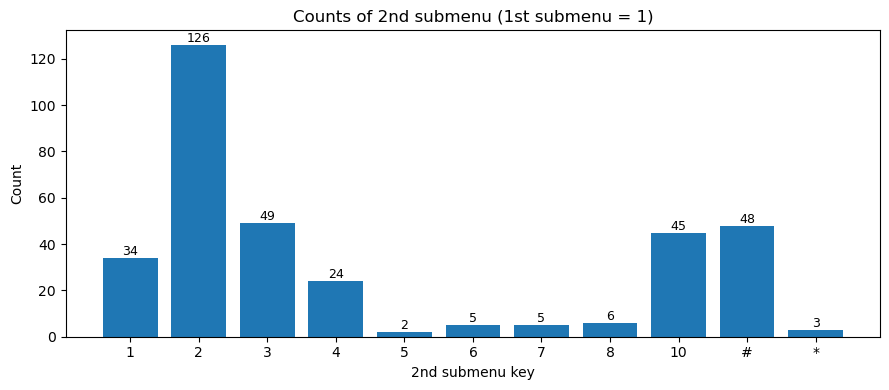

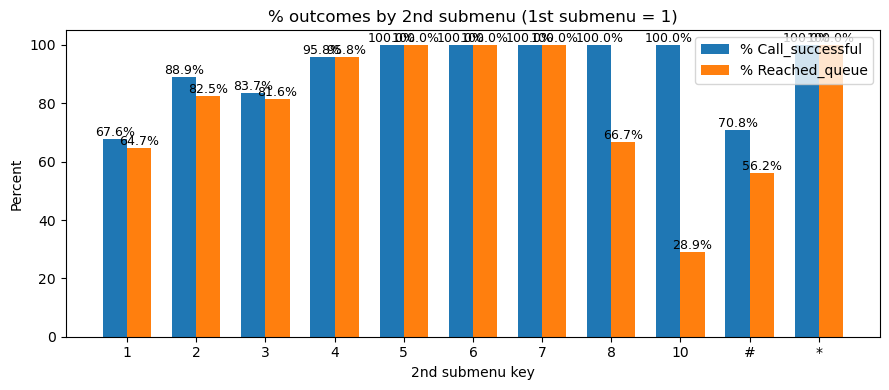

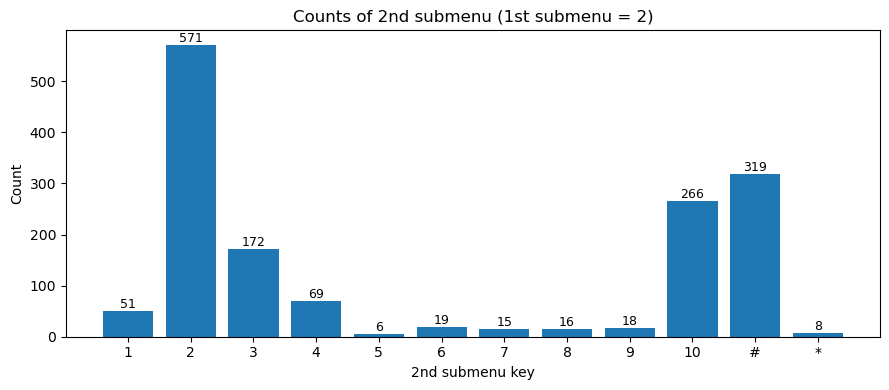

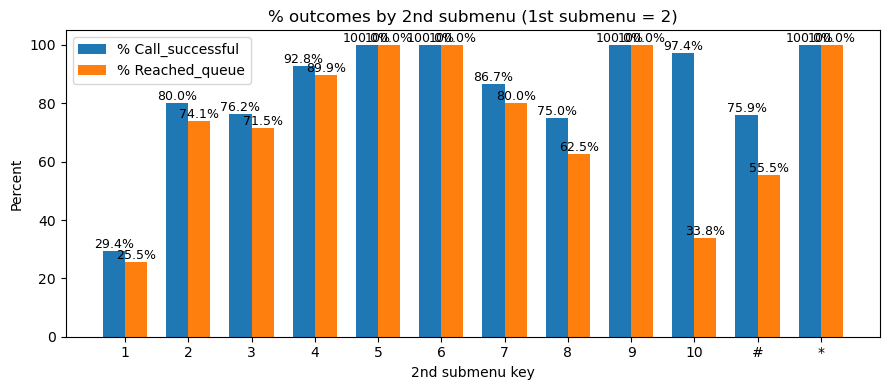

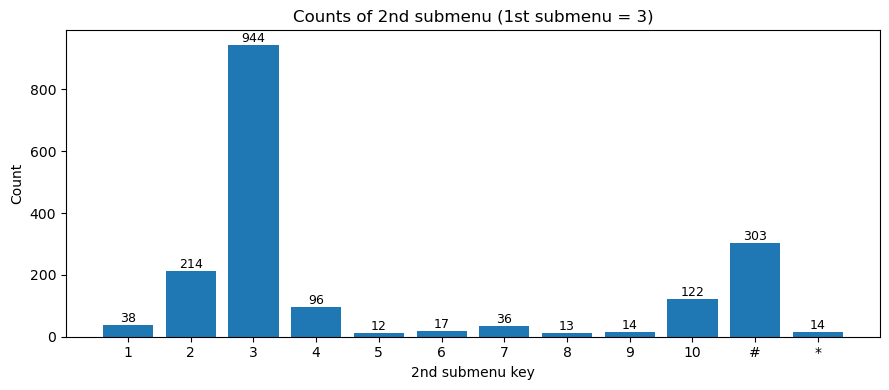

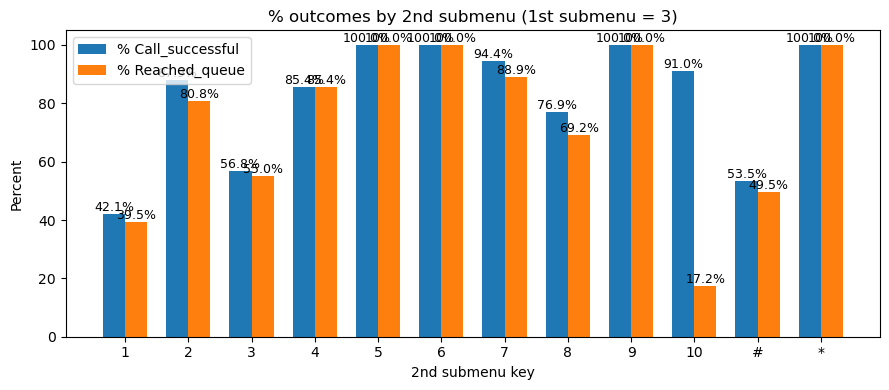

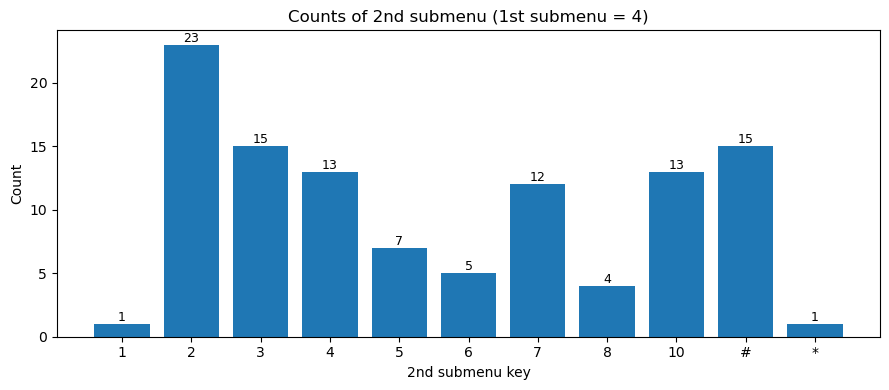

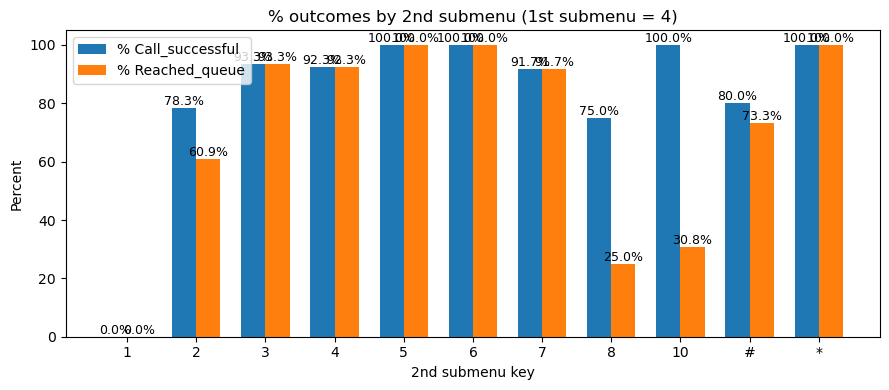

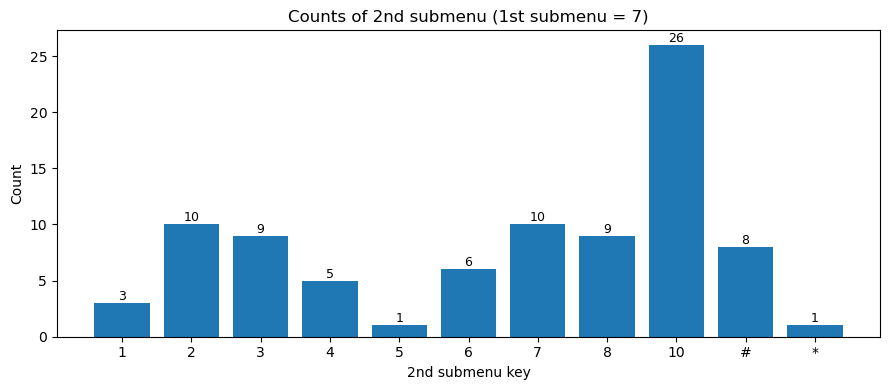

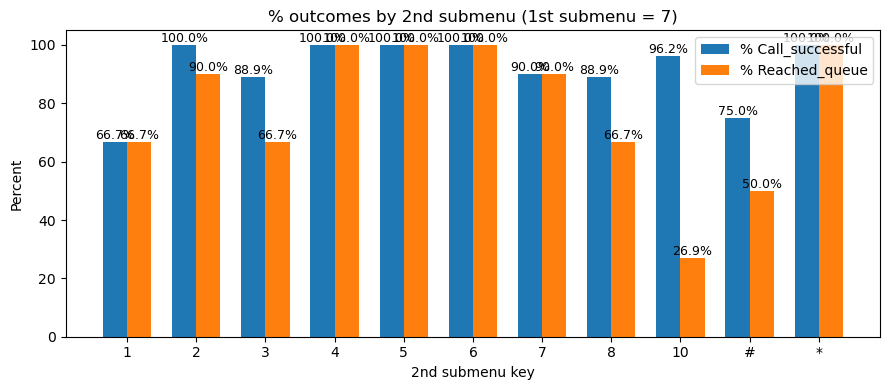

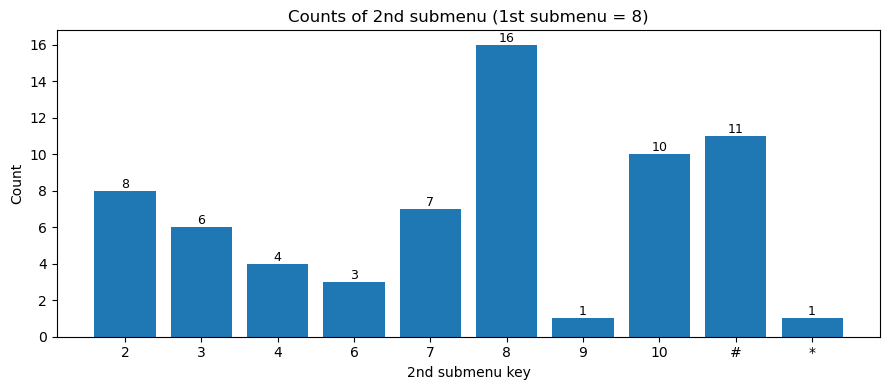

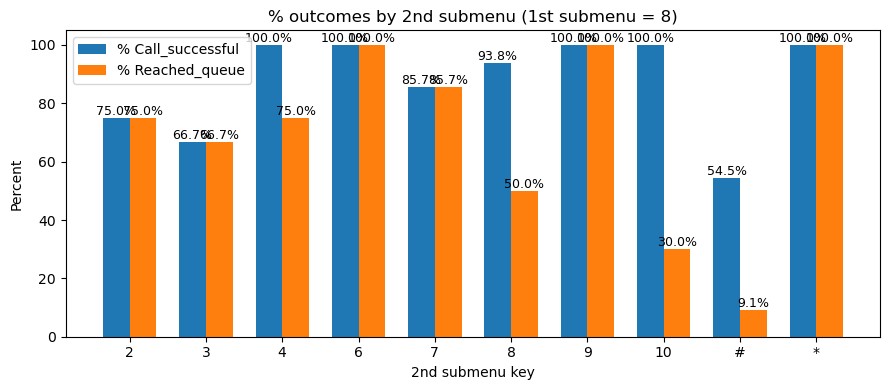

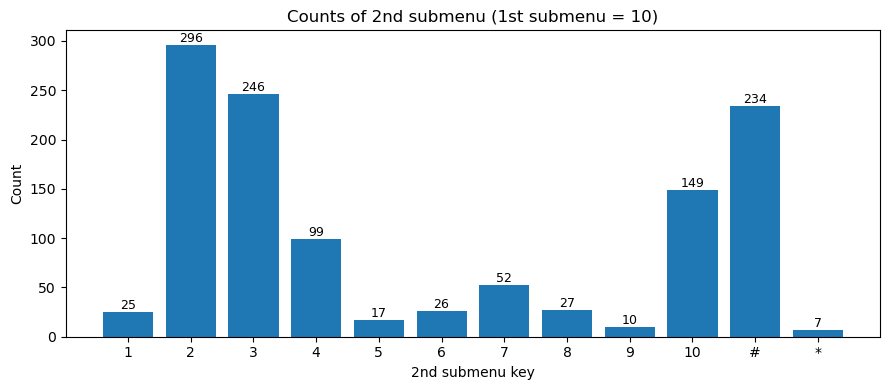

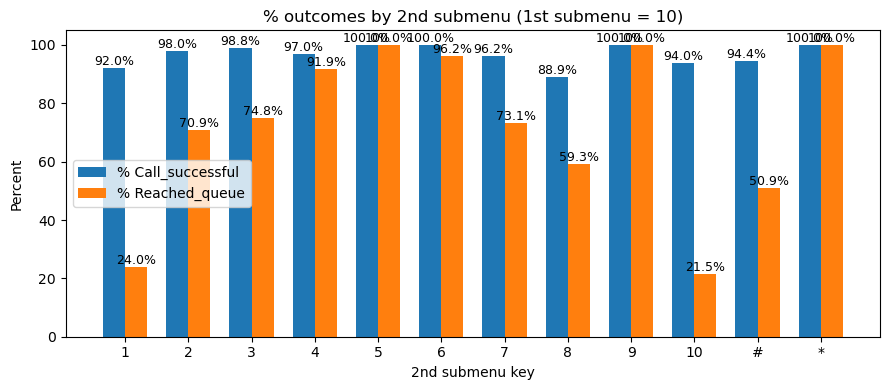

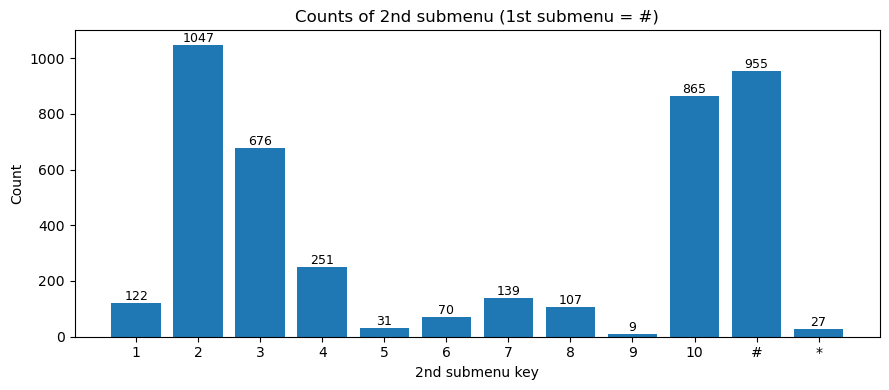

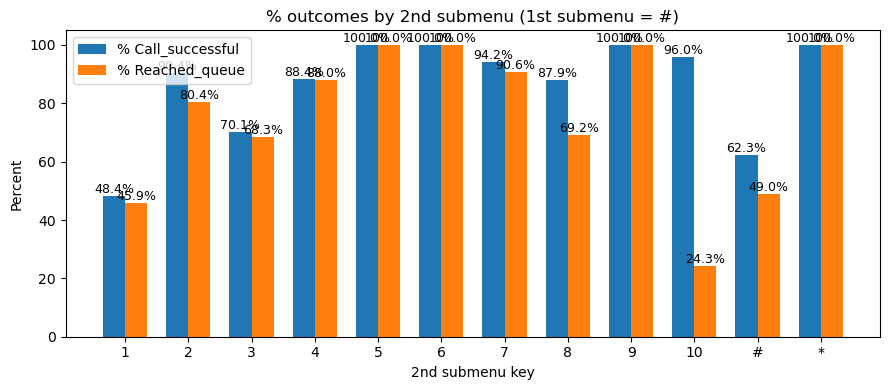

In [46]:
# --- mapping from key -> submenu(s) (for ordering/name reference if needed) ---
key_to_submenus = {
    '1':  'HIVMenu',
    '2':  'FamilyMenu',
    '3':  'HousingMenu',
    '4':  'BenefitsMenu',
    '5':  'GetLoggedInConsumerAgents | GetLoggedInConsumerSPAgents',
    '6':  'CriminalRecordsVoicemailTransfer',
    '7':  'EmploymentMenu',
    '8':  'ImmigrationMenu',
    '9':  'GetLoggedInADAPTAgents | GetLoggedInADAPTSPAgents',
    '10': 'OtherLegalMenu',
    '#':  'LegalMenu2',
    '*':  'FrontDeskTransfer | HolidayPrompt',
    'NoNextMenu': '—',
    'Unknown':    '—',
}

# same activity -> key function you’ve been using
def activity_to_key(activity: object) -> str:
    if pd.isna(activity): return 'NoNextMenu'
    s = str(activity).strip().lower()
    if s == 'hivmenu': return '1'
    if s == 'familymenu': return '2'
    if s == 'housingmenu': return '3'
    if s == 'benefitsmenu': return '4'
    if s in ('getloggedinconsumeragents', 'getloggedinconsumerspagents'): return '5'
    if s == 'criminalrecordsvoicemailtransfer': return '6'
    if s == 'employmentmenu': return '7'
    if s == 'immigrationmenu': return '8'
    if s in ('getloggedinadaptagents', 'getloggedinadaptspagents'): return '9'
    if s == 'otherlegalmenu': return '10'
    if s == 'legalmenu2': return '#'
    if s in ('frontdesktransfer', 'holidayprompt'): return '*'
    return 'Unknown'

# --- 1) Collapse to one row per Contact Session ID with the fields we need ---
session_df = (
    df_filt[['Contact Session ID',
             'After_first_LegalMenu2_activity',
             'After_second_LegalMenu2_activity',
             'Call_successful',   # new definition: queue OR dead-end
             'Reached_queue']]    # queue only
    .drop_duplicates(subset='Contact Session ID')
    .copy()
)

session_df['After_first_key']  = session_df['After_first_LegalMenu2_activity'].map(activity_to_key)
session_df['After_second_key'] = session_df['After_second_LegalMenu2_activity'].map(activity_to_key)

# only look at sessions that actually chose something after the 2nd legal menu
session_df = session_df[
    session_df['After_second_key'].notna()
    & (session_df['After_second_key'] != 'NoNextMenu')
    & (session_df['After_second_key'] != 'Unknown')
].copy()

# fixed order for x-axis
x_order = ['1','2','3','4','5','6','7','8','9','10','#','*']

# first submenus we care about
first_keys = ['1','2','3','4','5','6','7','8','9','10','#','*']

for k in first_keys:
    sub = session_df[session_df['After_first_key'] == k]
    if sub.empty:
        continue

    # ---------- Plot 1: counts of second submenu ----------
    counts = (
        sub['After_second_key']
        .value_counts()
        .reindex(x_order)
        .fillna(0)
        .astype(int)
    )
    # only nonzero ones
    mask = counts > 0
    plot_keys   = counts.index[mask]
    plot_counts = counts[mask]

    plt.figure(figsize=(9, 4))
    bars = plt.bar(range(len(plot_counts)), plot_counts.values)
    plt.title(f"Counts of 2nd submenu (1st submenu = {k})")
    plt.xlabel("2nd submenu key")
    plt.ylabel("Count")
    plt.xticks(range(len(plot_counts)), plot_keys, ha='center', rotation=0)
    for r, v in zip(bars, plot_counts.values):
        plt.text(r.get_x() + r.get_width()/2, r.get_height(), f"{int(v)}",
                 ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

  # ---------- Plot 2: % Call_successful vs % Reached_queue ----------
    grp = sub.groupby('After_second_key')
    pct_success = (grp['Call_successful'].mean() * 100).reindex(x_order)
    pct_queue   = (grp['Reached_queue'].mean() * 100).reindex(x_order)
    
    pct_success = pct_success[mask]
    pct_queue   = pct_queue[mask]
    
    x = np.arange(len(plot_keys))
    width = 0.35
    
    plt.figure(figsize=(9, 4))
    b1 = plt.bar(x - width/2, pct_success.values, width, label='% Call_successful')
    b2 = plt.bar(x + width/2, pct_queue.values,   width, label='% Reached_queue')
    
    plt.title(f"% outcomes by 2nd submenu (1st submenu = {k})")
    plt.xlabel("2nd submenu key")
    plt.ylabel("Percent")
    plt.xticks(x, plot_keys, ha='center', rotation=0)
    
    # give some headroom so 100% labels don't get clipped
    max_pct = max(pct_success.max(), pct_queue.max())
    plt.ylim(0, min(105, max_pct + 5))
    
    plt.legend()
    
    # labels on bars
    for r, v in zip(b1, pct_success.values):
        plt.text(r.get_x() + r.get_width()/2, r.get_height(),
                 f"{v:.1f}%", ha='center', va='bottom', fontsize=9)
    for r, v in zip(b2, pct_queue.values):
        plt.text(r.get_x() + r.get_width()/2, r.get_height(),
                 f"{v:.1f}%", ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
